# Tüm feature ve target alternatifleri: korelasyon ısı haritaları

Bu defter, proje klasöründeki aylık veri kaynaklarını tek zaman ekseninde birleştirir ve şu görünümleri üretir:

1. Ham sayısal feature'ların Pearson ve Spearman korelasyonları,
2. Modellemeye daha uygun dönüşümlerden sonra feature korelasyonları,
3. Bütün target alternatiflerinin kendi aralarındaki korelasyonlar,
4. Feature–target eşzamanlı korelasyonları,
5. Tahmin anına göre hizalanmış feature–gelecek target korelasyonları,
6. Her korelasyon için ortak gözlem sayıları.

> **Önemli:** Korelasyon nedensellik değildir. Zaman serilerindeki ortak trendler ham seviye korelasyonlarını yapay biçimde yükseltebilir. Bu nedenle ham ve dönüştürülmüş matrisler ayrı gösterilir.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="white", context="notebook")
RANDOM_STATE = 42

## 1. Proje yolu ve yardımcı fonksiyonlar

Notebook hem proje ana klasöründen hem de `notebooks/` klasöründen çalıştırılabilir. `oku_aylik` fonksiyonu tarihleri ay başına sabitler, seçilen sütunları sayısala çevirir ve aynı aya ait tekrarları reddeder.

In [2]:
PROJE_KOKU = Path.cwd()
if not (PROJE_KOKU / "data").exists():
    PROJE_KOKU = PROJE_KOKU.parent

DATA_DIR = PROJE_KOKU / "data"
CIKTI_DIR = PROJE_KOKU / "outputs" / "korelasyon_isi_haritalari"
CIKTI_DIR.mkdir(parents=True, exist_ok=True)

def oku_aylik(goreli_yol, sutunlar, tarih_sutunu="referans_ayi", yeni_adlar=None):
    yol = DATA_DIR / goreli_yol
    tablo = pd.read_csv(yol)
    gerekli = [tarih_sutunu, *sutunlar]
    eksik = [sutun for sutun in gerekli if sutun not in tablo.columns]
    if eksik:
        raise KeyError(f"{yol.name} içinde eksik sütunlar: {eksik}")

    tablo = tablo[gerekli].copy()
    tablo[tarih_sutunu] = (
        pd.to_datetime(tablo[tarih_sutunu], errors="coerce")
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    tablo = tablo.dropna(subset=[tarih_sutunu])

    for sutun in sutunlar:
        tablo[sutun] = pd.to_numeric(tablo[sutun], errors="coerce")

    if yeni_adlar:
        tablo = tablo.rename(columns=yeni_adlar)

    tarih_adi = yeni_adlar.get(tarih_sutunu, tarih_sutunu) if yeni_adlar else tarih_sutunu
    if tablo[tarih_adi].duplicated().any():
        tekrarlar = tablo.loc[tablo[tarih_adi].duplicated(False), tarih_adi].tolist()
        raise ValueError(f"{yol.name} içinde yinelenen aylar var: {tekrarlar}")

    return tablo.sort_values(tarih_adi).reset_index(drop=True)

print("Proje kökü:", PROJE_KOKU.resolve())
print("Grafik çıktı klasörü:", CIKTI_DIR.resolve())

Proje kökü: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2
Grafik çıktı klasörü: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2\outputs\korelasyon_isi_haritalari


## 2. Bütün aylık sayısal feature'ları oku ve birleştir

Aynı değişkenin farklı tarih aralıklarını içeren kopya dosyaları kullanılmaz; her kaynak için en uzun ve güncel seri seçilir. Yıllık değişim sütunları önceki talebimiz gereği dahil edilmez. `otv_ay_farki_en_yakin_olay` gelecekteki en yakın olayı da kullanabildiği için veri sızıntısı riski taşır ve feature listesine alınmaz.

In [3]:
kaynak_tablolari = []

kaynak_tablolari.append(oku_aylik(
    "noter_devir/noter_devir_2015_bugun_aylik.csv",
    ["noter_devir_toplam_adet", "noter_devir_otomobil_adet"],
))

kaynak_tablolari.append(oku_aylik(
    "odmd/odmd_2015_bugun_aylik.csv",
    ["odmd_toplam_adet", "odmd_otomobil_adet", "odmd_hta_adet"],
))

kaynak_tablolari.append(oku_aylik(
    "osd/osd_2024_bugun_aylik.csv",
    ["osd_binek_adet", "osd_kamyonet_adet", "osd_binek_kamyonet_toplam_adet"],
))

kaynak_tablolari.append(oku_aylik(
    "tufe/tufe_2024_bugun_aylik.csv",
    ["tufe_endeks", "tufe_aylik_degisim"],
))

kaynak_tablolari.append(oku_aylik(
    "tuketici_guveni/tuketici_guveni_2024_bugun_aylik.csv",
    ["tuketici_guven_endeksi", "otomobil_satinalma_ihtimali_endeksi"],
))

kaynak_tablolari.append(oku_aylik(
    "faiz/faizler_2024_bugun_aylik.csv",
    ["tasit_kredisi_faiz", "politika_faizi"],
))

kaynak_tablolari.append(oku_aylik(
    "usdtry/usdtry_2015_bugun_aylik.csv",
    [
        "usdtry_aysonu_alis", "usdtry_aysonu_satis", "usdtry_aysonu",
        "usdtry_ortalama_alis", "usdtry_ortalama_satis", "usdtry_ortalama",
    ],
))

kaynak_tablolari.append(oku_aylik(
    "altintry/altintry_aylik_2015_bugun.csv",
    ["altin_gram_try"],
))

kaynak_tablolari.append(oku_aylik(
    "alim_gucu/alim_gucu_2018_bugun_aylik.csv",
    ["brut_ucret_maas_endeksi_2021_100"],
))

kaynak_tablolari.append(oku_aylik(
    "indicata/indicata_aylik.csv",
    [
        "ilan_yayinlanan_adet", "satisa_donen_adet",
        "satis_ilan_orani_pct", "ortalama_satis_hizi_gun",
        "perakende_fiyat_aylik_pct", "toptan_fiyat_aylik_pct",
    ],
    yeni_adlar={
        "ilan_yayinlanan_adet": "indicata_ilan_yayinlanan_adet",
        "satisa_donen_adet": "indicata_satisa_donen_adet",
        "satis_ilan_orani_pct": "indicata_satis_ilan_orani_pct",
        "ortalama_satis_hizi_gun": "indicata_ortalama_satis_hizi_gun",
        "perakende_fiyat_aylik_pct": "indicata_perakende_fiyat_aylik_pct",
        "toptan_fiyat_aylik_pct": "indicata_toptan_fiyat_aylik_pct",
    },
))

kaynak_tablolari.append(oku_aylik(
    "arabamcom/arabamcom_aylik_fiyat.csv",
    ["ortalama_ilan_fiyati_tl", "reel_aylik_degisim_pct"],
    yeni_adlar={
        "ortalama_ilan_fiyati_tl": "arabam_ortalama_ilan_fiyati_tl",
        "reel_aylik_degisim_pct": "arabam_reel_aylik_degisim_pct",
    },
))

kaynak_tablolari.append(oku_aylik(
    "proxy_fiyat/proxy_fiyat_2024_bugun_raw.csv",
    ["proxy_fiyat_cari_tl", "proxy_talep_aylik_pct", "proxy_satis_orani_pct", "proxy_dom_gun"],
    yeni_adlar={
        "proxy_fiyat_cari_tl": "betam_ortalama_ilan_fiyati_tl",
        "proxy_talep_aylik_pct": "betam_talep_aylik_pct",
        "proxy_satis_orani_pct": "betam_satis_orani_pct",
        "proxy_dom_gun": "betam_dom_gun",
    },
))

kaynak_tablolari.append(oku_aylik(
    "otv/otv_olaylari_2015_bugun_aylik.csv",
    ["otv_event_ay_mi"],
))

# EUR/TRY günlük serisini aylık ortalama ve ay sonu değerine dönüştür.
eur_gunluk = pd.read_csv(DATA_DIR / "eurtry/eurtry_gunluk_2015_bugun.csv")
eur_gunluk["tarih"] = pd.to_datetime(eur_gunluk["tarih"], errors="coerce")
eur_gunluk["eurtry_orta"] = pd.to_numeric(eur_gunluk["eurtry_orta"], errors="coerce")
eur_gunluk = eur_gunluk.dropna(subset=["tarih", "eurtry_orta"]).sort_values("tarih")
eur_gunluk["referans_ayi"] = eur_gunluk["tarih"].dt.to_period("M").dt.to_timestamp()
eur_aylik = (
    eur_gunluk.groupby("referans_ayi", as_index=False)
    .agg(eurtry_ortalama=("eurtry_orta", "mean"), eurtry_aysonu=("eurtry_orta", "last"))
)
kaynak_tablolari.append(eur_aylik)

# BETAM fiyatını iki doğrulanmış 2023 gözlemiyle geriye uzat.
betam_2023 = oku_aylik(
    "betam/betam_2023_eksik_tamamlayici.csv",
    ["ortalama_ilan_fiyati_tl"],
    yeni_adlar={"ortalama_ilan_fiyati_tl": "betam_ortalama_ilan_fiyati_tl"},
)
betam_tablo_index = next(
    i for i, tablo in enumerate(kaynak_tablolari)
    if "betam_ortalama_ilan_fiyati_tl" in tablo.columns
)
kaynak_tablolari[betam_tablo_index] = (
    pd.concat([betam_2023, kaynak_tablolari[betam_tablo_index]], ignore_index=True)
    .sort_values("referans_ayi")
    .drop_duplicates("referans_ayi", keep="last")
)

# Ana takvim, otomobil noter devrinin geçerli olduğu dönemdir.
noter = kaynak_tablolari[0]
baslangic = noter.loc[noter["noter_devir_otomobil_adet"].notna(), "referans_ayi"].min()
bitis = noter.loc[noter["noter_devir_otomobil_adet"].notna(), "referans_ayi"].max()
veri = pd.DataFrame({"referans_ayi": pd.date_range(baslangic, bitis, freq="MS")})

for tablo in kaynak_tablolari:
    yeni_sutunlar = [c for c in tablo.columns if c != "referans_ayi" and c not in veri.columns]
    if yeni_sutunlar:
        veri = veri.merge(tablo[["referans_ayi", *yeni_sutunlar]], on="referans_ayi", how="left")

veri = veri.sort_values("referans_ayi").reset_index(drop=True)

print(f"Birleşik veri: {veri.shape[0]} ay × {veri.shape[1] - 1} ham sayısal feature")
print(veri["referans_ayi"].min().strftime("%Y-%m"), "→", veri["referans_ayi"].max().strftime("%Y-%m"))
display(veri.head())

Birleşik veri: 102 ay × 37 ham sayısal feature
2018-01 → 2026-06


,referans_ayi,noter_devir_toplam_adet,noter_devir_otomobil_adet,odmd_toplam_adet,odmd_otomobil_adet,odmd_hta_adet,osd_binek_adet,osd_kamyonet_adet,osd_binek_kamyonet_toplam_adet,tufe_endeks,tufe_aylik_degisim,tuketici_guven_endeksi,otomobil_satinalma_ihtimali_endeksi,tasit_kredisi_faiz,politika_faizi,usdtry_aysonu_alis,usdtry_aysonu_satis,usdtry_aysonu,usdtry_ortalama_alis,usdtry_ortalama_satis,usdtry_ortalama,altin_gram_try,brut_ucret_maas_endeksi_2021_100,indicata_ilan_yayinlanan_adet,indicata_satisa_donen_adet,indicata_satis_ilan_orani_pct,indicata_ortalama_satis_hizi_gun,indicata_perakende_fiyat_aylik_pct,indicata_toptan_fiyat_aylik_pct,arabam_ortalama_ilan_fiyati_tl,arabam_reel_aylik_degisim_pct,betam_ortalama_ilan_fiyati_tl,betam_talep_aylik_pct,betam_satis_orani_pct,betam_dom_gun,otv_event_ay_mi,eurtry_ortalama,eurtry_aysonu
0,2018-01-01,631823,"445,255.0000",35076,"26,611.0000","8,465.0000","85,368.0000","32,222.0000","117,590.0000",330.7500,1.0201,92.3832,13.2876,14.1700,12.7500,3.7795,3.7863,3.7829,3.7723,3.7791,3.7757,162.0900,55.0778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.5921,4.6866
1,2018-02-01,597953,"419,533.0000",47009,"35,901.0000","11,108.0000","94,113.0000","39,738.0000","133,851.0000",333.1700,0.7317,92.9742,12.3894,14.6825,12.7500,3.7833,3.7901,3.7867,3.7780,3.7848,3.7814,162.6600,55.0778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.6774,4.6688
2,2018-03-01,681359,"478,648.0000",76345,"59,798.0000","16,547.0000","105,687.0000","45,190.0000","150,877.0000",336.4800,0.9935,92.2755,13.8006,14.7880,12.7500,3.9949,4.0021,3.9985,3.8809,3.8879,3.8844,166.2500,55.0778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.7898,4.9235
3,2018-04-01,684291,"479,866.0000",71126,"55,108.0000","16,018.0000","90,789.0000","38,848.0000","129,637.0000",342.7800,1.8723,91.6511,12.9188,14.8300,12.8625,4.0535,4.0608,4.0572,4.0530,4.0604,4.0567,174.6900,56.1419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.9875,4.9005
4,2018-05-01,672053,"472,478.0000",72755,"57,227.0000","15,528.0000","95,677.0000","43,690.0000","139,367.0000",348.3400,1.6220,90.9487,12.5689,13.8775,14.3182,4.4834,4.4914,4.4874,4.3979,4.4058,4.4018,187.2200,56.1419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5.2126,5.2111


## 3. Target alternatiflerini oluştur

Target'lar gerçekleşme ayına yazılır; hiçbir target hesabında negatif `shift` kullanılmaz. Böylece satırın tarihinden sonraki bilgi o satıra taşınmaz.

- **Log hız:** `100 × ln(A/B)`; sınırsızdır ve toplamsal yorumlanır.
- **Tam yüzde değişim:** `100 × (A/B − 1)`; iş dilinde daha doğrudan okunur.
- **Simetrik hız:** `(A − B)/(A + B)`; doğal olarak `(-1, 1)` aralığındadır.
- **Indicata alternatifleri:** noter devri değil, online ilandan satışa dönmüş kabul edilen araç proxy'sidir.
- **Fiyat alternatifi:** gerçekleşen satış fiyatı değil, arabam.com ortalama ilan fiyatıdır.

In [4]:
targetlar = pd.DataFrame({"referans_ayi": veri["referans_ayi"]})

V = veri["noter_devir_otomobil_adet"]
Q3 = V.rolling(3, min_periods=3).sum()

targetlar["noter_1ay_log_hiz"] = 100 * np.log(V / V.shift(1))
targetlar["noter_1ay_yuzde_degisim"] = 100 * (V / V.shift(1) - 1)
targetlar["noter_1ay_simetrik_hiz"] = (V - V.shift(1)) / (V + V.shift(1))

targetlar["noter_3ay_log_hiz"] = 100 * np.log(Q3 / Q3.shift(3))
targetlar["noter_3ay_yuzde_degisim"] = 100 * (Q3 / Q3.shift(3) - 1)
targetlar["noter_3ay_simetrik_hiz"] = (Q3 - Q3.shift(3)) / (Q3 + Q3.shift(3))

I = veri["indicata_satisa_donen_adet"]
I3 = I.rolling(3, min_periods=3).sum()
L = veri["indicata_satis_ilan_orani_pct"]
L3 = L.rolling(3, min_periods=3).mean()
D = veri["indicata_ortalama_satis_hizi_gun"]

targetlar["indicata_1ay_hacim_log_hiz"] = 100 * np.log(I / I.shift(1))
targetlar["indicata_3ay_toplam_hacim_log_hiz"] = 100 * np.log(I3 / I3.shift(3))
targetlar["indicata_1ay_likidite_fark"] = L - L.shift(1)
targetlar["indicata_3ay_likidite_fark"] = L3 - L3.shift(3)
# Satış gününün azalması hızlanma olduğu için işareti ters çeviriyoruz.
targetlar["indicata_1ay_satis_hizi_iyilesme"] = D.shift(1) - D

P = veri["arabam_ortalama_ilan_fiyati_tl"]
targetlar["arabam_fiyat_1ay_log_hiz"] = 100 * np.log(P / P.shift(1))
targetlar["arabam_reel_aylik_degisim_pct"] = veri["arabam_reel_aylik_degisim_pct"]

target_bilgisi = pd.DataFrame([
    ("noter_1ay_log_hiz", 1, "Noter otomobil devri: 1 aylık log hız"),
    ("noter_1ay_yuzde_degisim", 1, "Noter otomobil devri: 1 aylık tam yüzde"),
    ("noter_1ay_simetrik_hiz", 1, "Noter otomobil devri: 1 aylık [-1, 1] hız"),
    ("noter_3ay_log_hiz", 3, "Noter otomobil devri: iki ayrık 3 aylık toplamın log hızı"),
    ("noter_3ay_yuzde_degisim", 3, "Noter otomobil devri: iki ayrık 3 aylık toplamın tam yüzdesi"),
    ("noter_3ay_simetrik_hiz", 3, "Noter otomobil devri: iki ayrık 3 aylık toplamın [-1, 1] hızı"),
    ("indicata_1ay_hacim_log_hiz", 1, "Indicata satışa dönen ilan: 1 aylık log hız"),
    ("indicata_3ay_toplam_hacim_log_hiz", 3, "Indicata satışa dönen ilan: iki ayrık 3 aylık toplam"),
    ("indicata_1ay_likidite_fark", 1, "Indicata satış/ilan oranı: 1 aylık yüzde-puan farkı"),
    ("indicata_3ay_likidite_fark", 3, "Indicata satış/ilan oranı: iki ayrık 3 aylık ortalama farkı"),
    ("indicata_1ay_satis_hizi_iyilesme", 1, "Indicata satış günü azalması: pozitif değer hızlanmadır"),
    ("arabam_fiyat_1ay_log_hiz", 1, "arabam.com ortalama ilan fiyatı: 1 aylık log hız"),
    ("arabam_reel_aylik_degisim_pct", 1, "arabam.com yayımlanmış reel aylık değişim"),
], columns=["target", "tahmin_ufku_ay", "aciklama"])

target_bilgisi["gecerli_gozlem"] = target_bilgisi["target"].map(targetlar.notna().sum())
target_bilgisi["ilk_gecerli_ay"] = target_bilgisi["target"].map(
    lambda c: targetlar.loc[targetlar[c].notna(), "referans_ayi"].min()
)
target_bilgisi["son_gecerli_ay"] = target_bilgisi["target"].map(
    lambda c: targetlar.loc[targetlar[c].notna(), "referans_ayi"].max()
)
display(target_bilgisi)

,target,tahmin_ufku_ay,aciklama,gecerli_gozlem,ilk_gecerli_ay,son_gecerli_ay
0,noter_1ay_log_hiz,1,Noter otomobil devri: 1 aylık log hız,101,2018-02-01,2026-06-01
1,noter_1ay_yuzde_degisim,1,Noter otomobil devri: 1 aylık tam yüzde,101,2018-02-01,2026-06-01
2,noter_1ay_simetrik_hiz,1,"Noter otomobil devri: 1 aylık [-1, 1] hız",101,2018-02-01,2026-06-01
3,noter_3ay_log_hiz,3,Noter otomobil devri: iki ayrık 3 aylık toplam...,97,2018-06-01,2026-06-01
4,noter_3ay_yuzde_degisim,3,Noter otomobil devri: iki ayrık 3 aylık toplam...,97,2018-06-01,2026-06-01
5,noter_3ay_simetrik_hiz,3,Noter otomobil devri: iki ayrık 3 aylık toplam...,97,2018-06-01,2026-06-01
6,indicata_1ay_hacim_log_hiz,1,Indicata satışa dönen ilan: 1 aylık log hız,41,2023-02-01,2026-06-01
7,indicata_3ay_toplam_hacim_log_hiz,3,Indicata satışa dönen ilan: iki ayrık 3 aylık ...,37,2023-06-01,2026-06-01
8,indicata_1ay_likidite_fark,1,Indicata satış/ilan oranı: 1 aylık yüzde-puan ...,41,2023-02-01,2026-06-01
9,indicata_3ay_likidite_fark,3,Indicata satış/ilan oranı: iki ayrık 3 aylık o...,37,2023-06-01,2026-06-01


## 4. Modellemeye daha uygun feature dönüşümleri

Sürekli büyüyen adet, fiyat, kur ve endeks seviyeleri bir aylık log değişime çevrilir. Oran, faiz, güven endeksi, aylık değişim ve olay değişkenleri kendi ölçeğinde bırakılır. Ham tablo ayrıca saklanır; böylece dönüşümün korelasyonu nasıl değiştirdiği görülebilir.

In [5]:
ham_feature_sutunlari = [c for c in veri.columns if c != "referans_ayi"]

log_degisim_sutunlari = [
    "noter_devir_toplam_adet", "noter_devir_otomobil_adet",
    "odmd_toplam_adet", "odmd_otomobil_adet", "odmd_hta_adet",
    "osd_binek_adet", "osd_kamyonet_adet", "osd_binek_kamyonet_toplam_adet",
    "tufe_endeks",
    "usdtry_aysonu_alis", "usdtry_aysonu_satis", "usdtry_aysonu",
    "usdtry_ortalama_alis", "usdtry_ortalama_satis", "usdtry_ortalama",
    "eurtry_aysonu", "eurtry_ortalama", "altin_gram_try",
    "brut_ucret_maas_endeksi_2021_100",
    "indicata_ilan_yayinlanan_adet", "indicata_satisa_donen_adet",
    "arabam_ortalama_ilan_fiyati_tl", "betam_ortalama_ilan_fiyati_tl",
]

model_feature = pd.DataFrame({"referans_ayi": veri["referans_ayi"]})
for sutun in ham_feature_sutunlari:
    seri = veri[sutun]
    if sutun in log_degisim_sutunlari:
        model_feature[f"{sutun}__log_degisim_1ay"] = 100 * np.log(seri / seri.shift(1))
    else:
        model_feature[sutun] = seri

model_feature_sutunlari = [c for c in model_feature.columns if c != "referans_ayi"]

feature_kapsama = pd.DataFrame({
    "feature": model_feature_sutunlari,
    "gecerli_gozlem": [model_feature[c].notna().sum() for c in model_feature_sutunlari],
    "eksik_orani_yuzde": [100 * model_feature[c].isna().mean() for c in model_feature_sutunlari],
    "benzersiz_deger": [model_feature[c].nunique(dropna=True) for c in model_feature_sutunlari],
}).sort_values(["gecerli_gozlem", "feature"])

print("Ham feature sayısı:", len(ham_feature_sutunlari))
print("Model-ready feature sayısı:", len(model_feature_sutunlari))
display(feature_kapsama)

Ham feature sayısı: 37
Model-ready feature sayısı: 37


,feature,gecerli_gozlem,eksik_orani_yuzde,benzersiz_deger
25,indicata_ortalama_satis_hizi_gun,11,89.2157,10
27,indicata_toptan_fiyat_aylik_pct,11,89.2157,11
29,arabam_reel_aylik_degisim_pct,16,84.3137,15
28,arabam_ortalama_ilan_fiyati_tl__log_degisim_1ay,24,76.4706,24
26,indicata_perakende_fiyat_aylik_pct,24,76.4706,23
30,betam_ortalama_ilan_fiyati_tl__log_degisim_1ay,27,73.5294,27
33,betam_dom_gun,28,72.5490,23
32,betam_satis_orani_pct,28,72.5490,22
31,betam_talep_aylik_pct,28,72.5490,28
22,indicata_ilan_yayinlanan_adet__log_degisim_1ay,41,59.8039,41


## 5. Isı haritası yardımcıları

`MIN_ORTAK_GOZLEM`, iki değişken arasında korelasyon göstermek için gereken en az ortak ay sayısıdır. Kısa seriler için eşiği azaltabilirsiniz; fakat küçük örneklem korelasyonları çok oynaktır.

In [6]:
MIN_ORTAK_GOZLEM = 12

def ortak_gozlem_matrisi(tablo):
    var_mi = tablo.notna().astype(int)
    return var_mi.T.dot(var_mi)

def korelasyon_ve_n(tablo, method="pearson", min_n=MIN_ORTAK_GOZLEM):
    corr = tablo.corr(method=method, min_periods=min_n)
    n = ortak_gozlem_matrisi(tablo)
    return corr, n

def kare_isi_haritasi(tablo, baslik, dosya_adi, method="pearson", annot=None):
    corr, n = korelasyon_ve_n(tablo, method=method)
    boyut = len(corr.columns)
    if annot is None:
        annot = boyut <= 18

    maske = np.triu(np.ones_like(corr, dtype=bool), k=1)
    fig, ax = plt.subplots(figsize=(max(12, 0.48 * boyut), max(10, 0.45 * boyut)))
    sns.heatmap(
        corr, mask=maske, cmap="vlag", center=0, vmin=-1, vmax=1,
        annot=annot, fmt=".2f", linewidths=0.25, linecolor="white",
        cbar_kws={"label": f"{method.title()} korelasyonu"}, ax=ax,
    )
    ax.set_title(baslik, pad=16)
    ax.tick_params(axis="x", rotation=75, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    plt.tight_layout()
    fig.savefig(CIKTI_DIR / dosya_adi, dpi=220, bbox_inches="tight")
    plt.show()
    return corr, n

def dikdortgen_isi_haritasi(corr, baslik, dosya_adi, annot=True):
    satir = len(corr.index)
    sutun = len(corr.columns)
    fig, ax = plt.subplots(figsize=(max(10, 1.25 * sutun), max(8, 0.38 * satir)))
    sns.heatmap(
        corr, cmap="vlag", center=0, vmin=-1, vmax=1,
        annot=annot, fmt=".2f", linewidths=0.25, linecolor="white",
        cbar_kws={"label": "Korelasyon"}, ax=ax,
    )
    ax.set_title(baslik, pad=16)
    ax.tick_params(axis="x", rotation=65, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    plt.tight_layout()
    fig.savefig(CIKTI_DIR / dosya_adi, dpi=220, bbox_inches="tight")
    plt.show()

def feature_target_corr(feature_df, target_df, method="pearson", min_n=MIN_ORTAK_GOZLEM):
    sonuc = pd.DataFrame(index=feature_df.columns, columns=target_df.columns, dtype=float)
    sayilar = pd.DataFrame(index=feature_df.columns, columns=target_df.columns, dtype=float)
    for feature in feature_df.columns:
        for target in target_df.columns:
            ortak = pd.concat([feature_df[feature], target_df[target]], axis=1).dropna()
            sayilar.loc[feature, target] = len(ortak)
            if len(ortak) >= min_n and ortak.iloc[:, 0].nunique() > 1 and ortak.iloc[:, 1].nunique() > 1:
                sonuc.loc[feature, target] = ortak.iloc[:, 0].corr(ortak.iloc[:, 1], method=method)
    return sonuc, sayilar

## 6. Ham feature korelasyonları

Bu matris veri denetimi içindir. Özellikle kur, fiyat, TÜFE ve ücret gibi trendli seviyelerde yüksek korelasyon görülmesi tek başına tahmin gücü değildir.

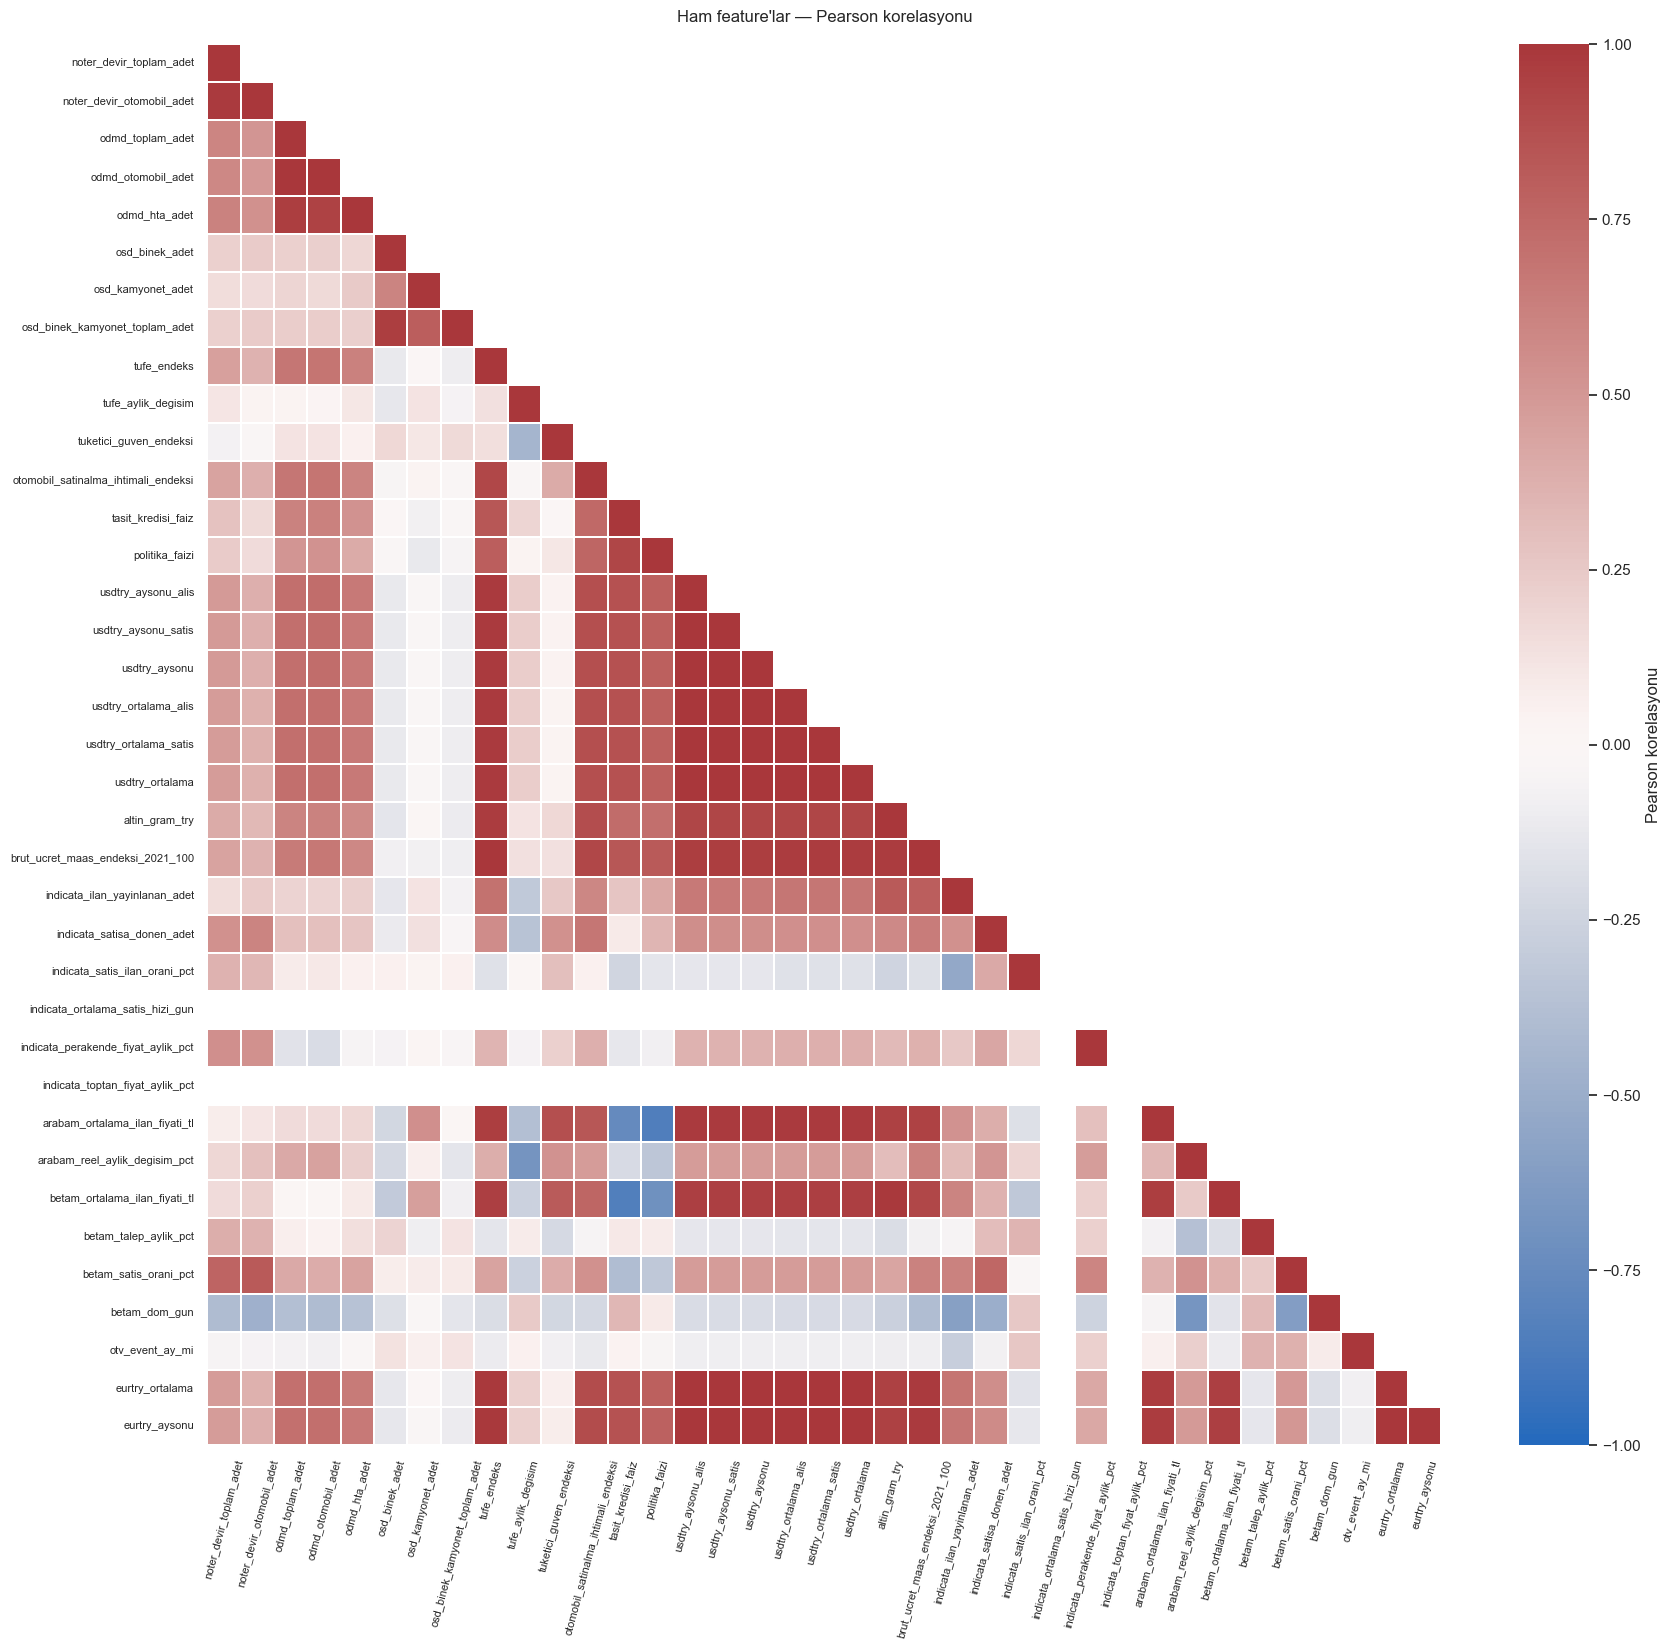

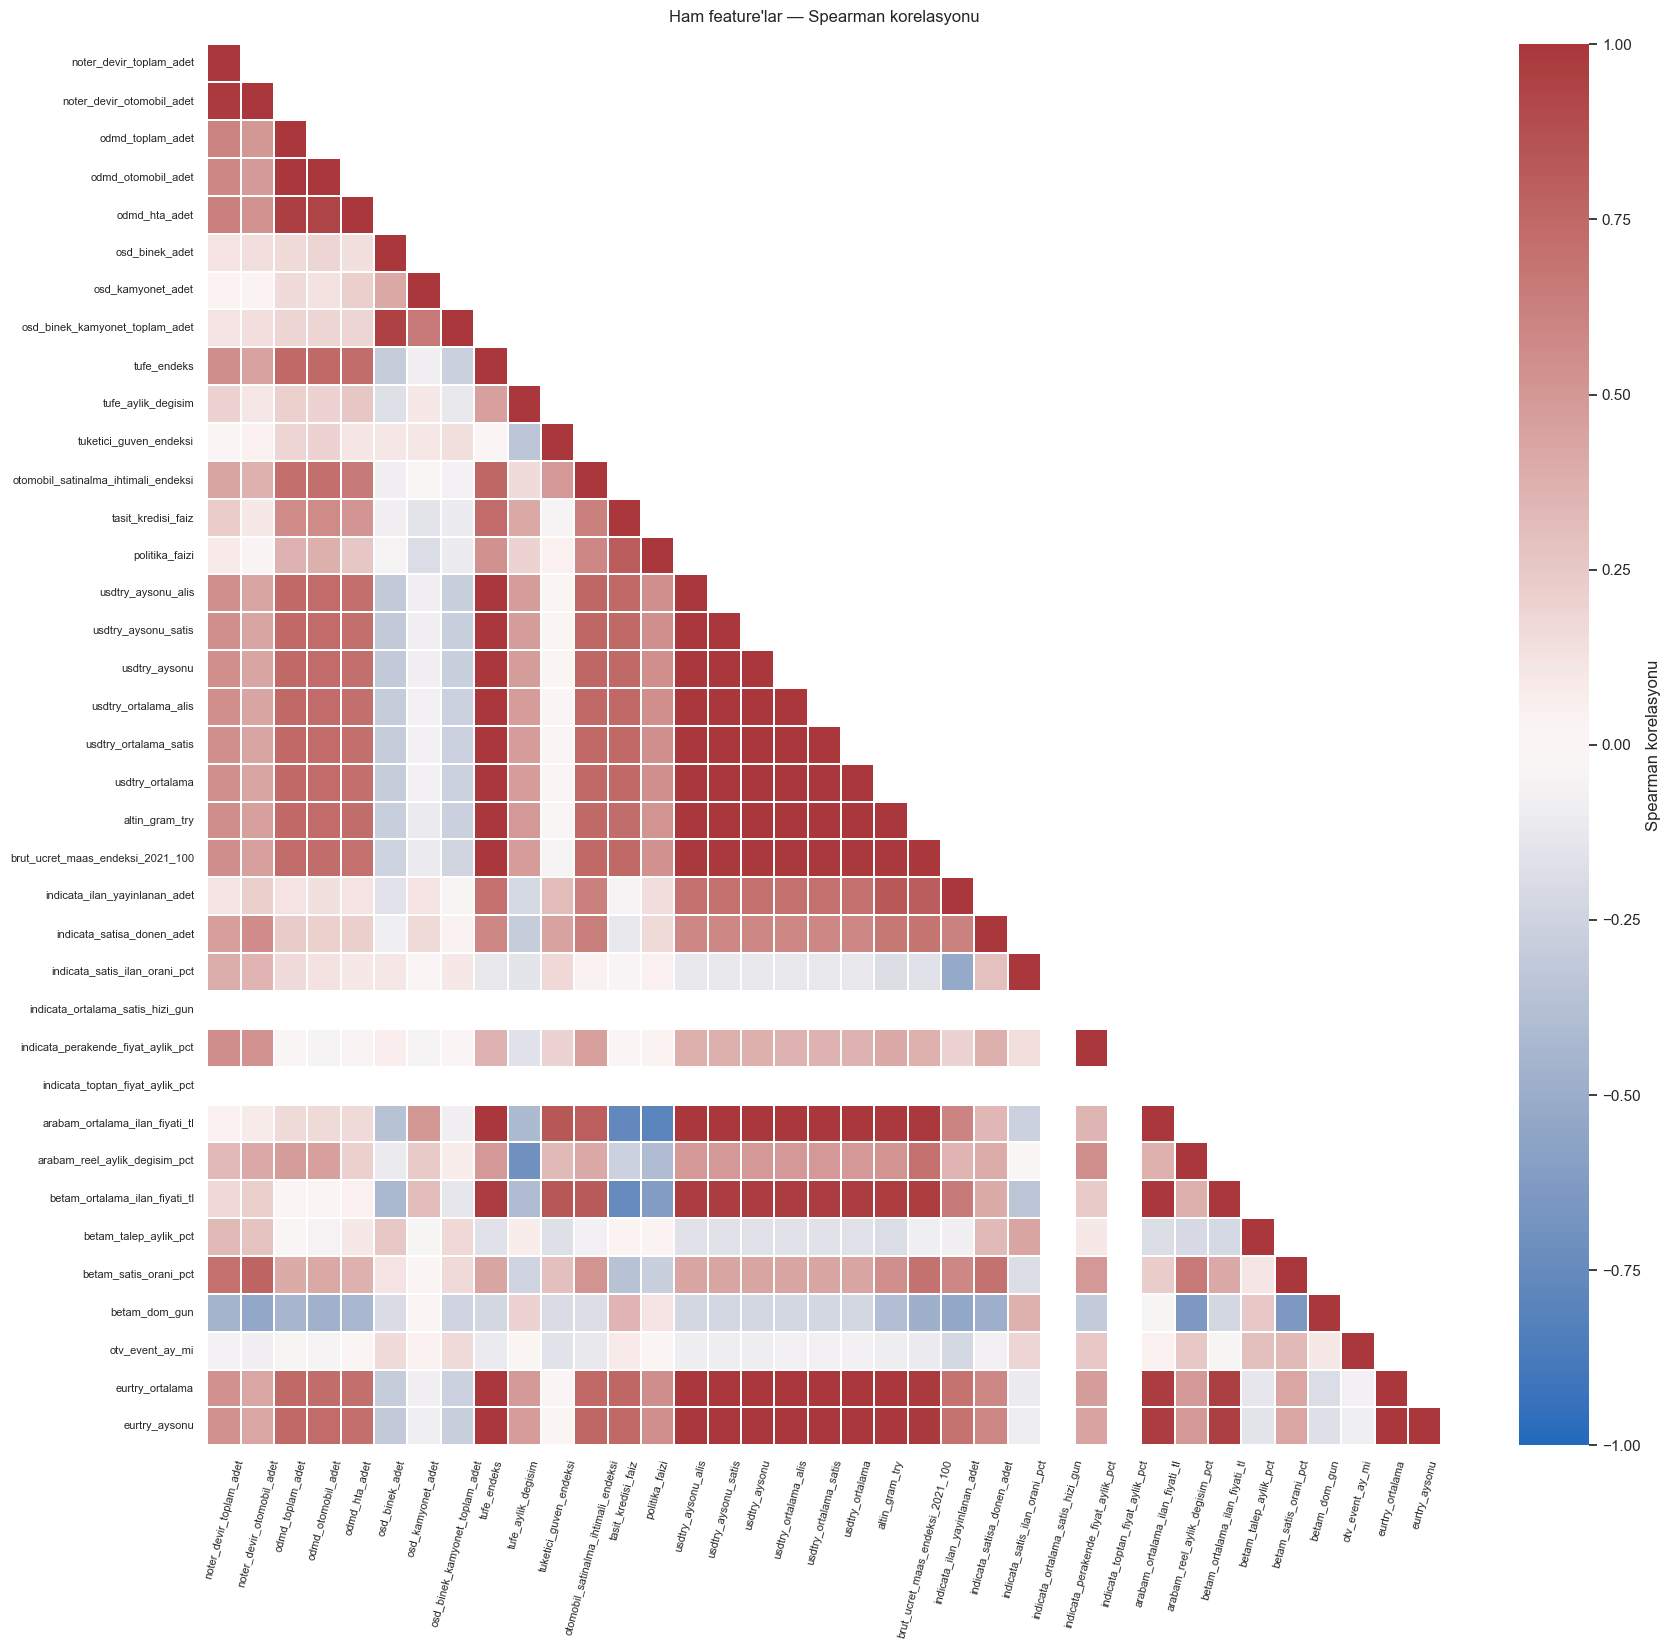

In [7]:
ham_sayisal = veri[ham_feature_sutunlari]
ham_pearson, ham_n = kare_isi_haritasi(
    ham_sayisal,
    "Ham feature'lar — Pearson korelasyonu",
    "01_ham_feature_pearson.png",
    method="pearson",
)
ham_spearman, _ = kare_isi_haritasi(
    ham_sayisal,
    "Ham feature'lar — Spearman korelasyonu",
    "02_ham_feature_spearman.png",
    method="spearman",
)

## 7. Model-ready feature korelasyonları

Trendli seviyeler bir aylık log değişime dönüştürüldüğü için bu matris, modelde birlikte kullanılacak değişkenler arasındaki çoklu doğrusal bağlantıyı değerlendirmek açısından daha anlamlıdır.

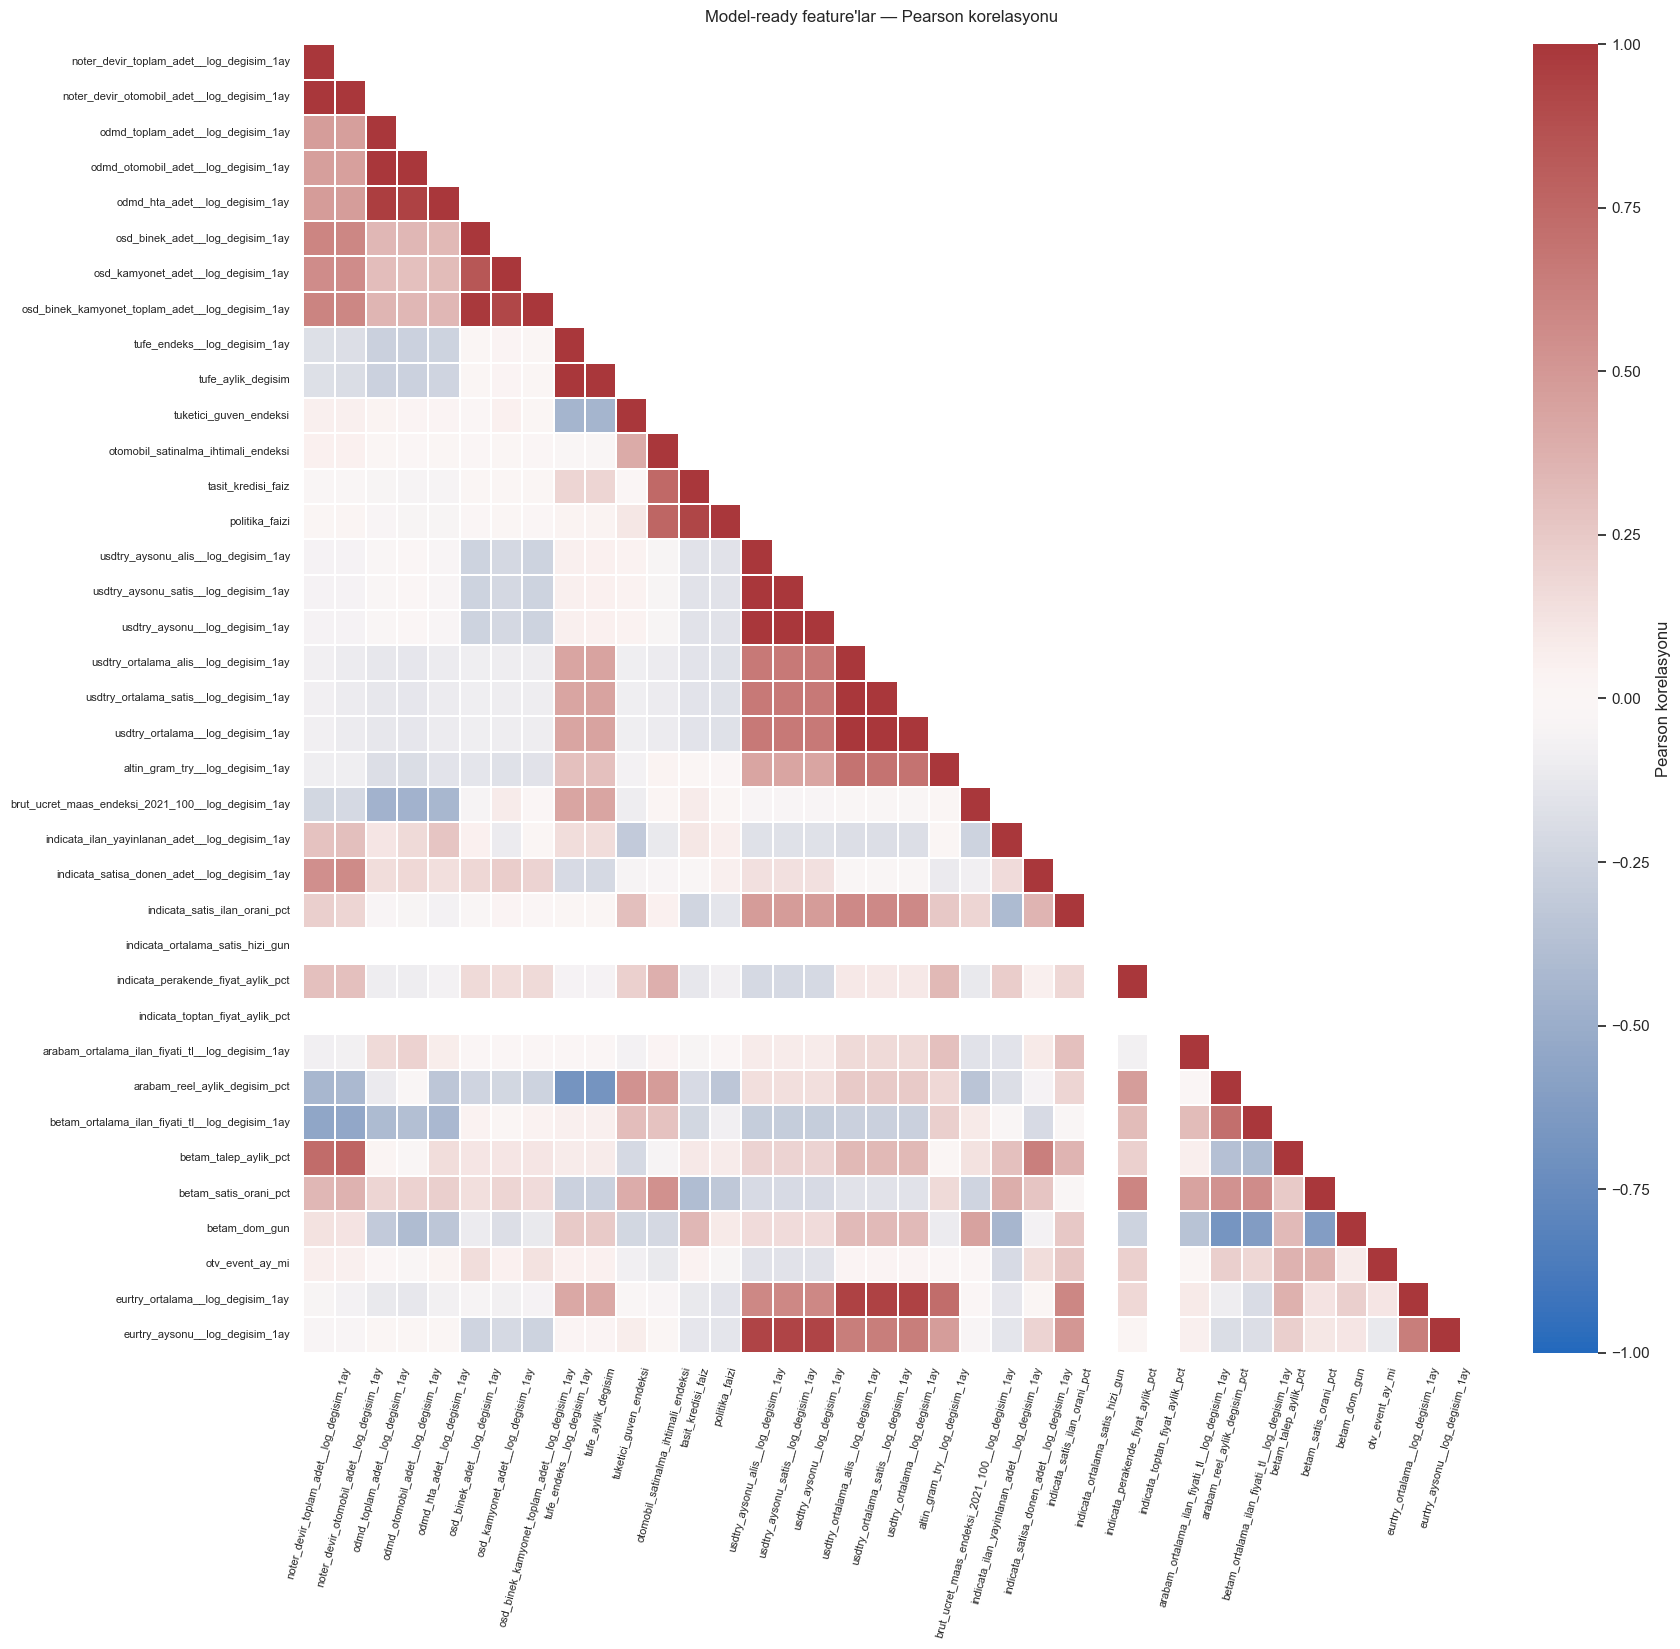

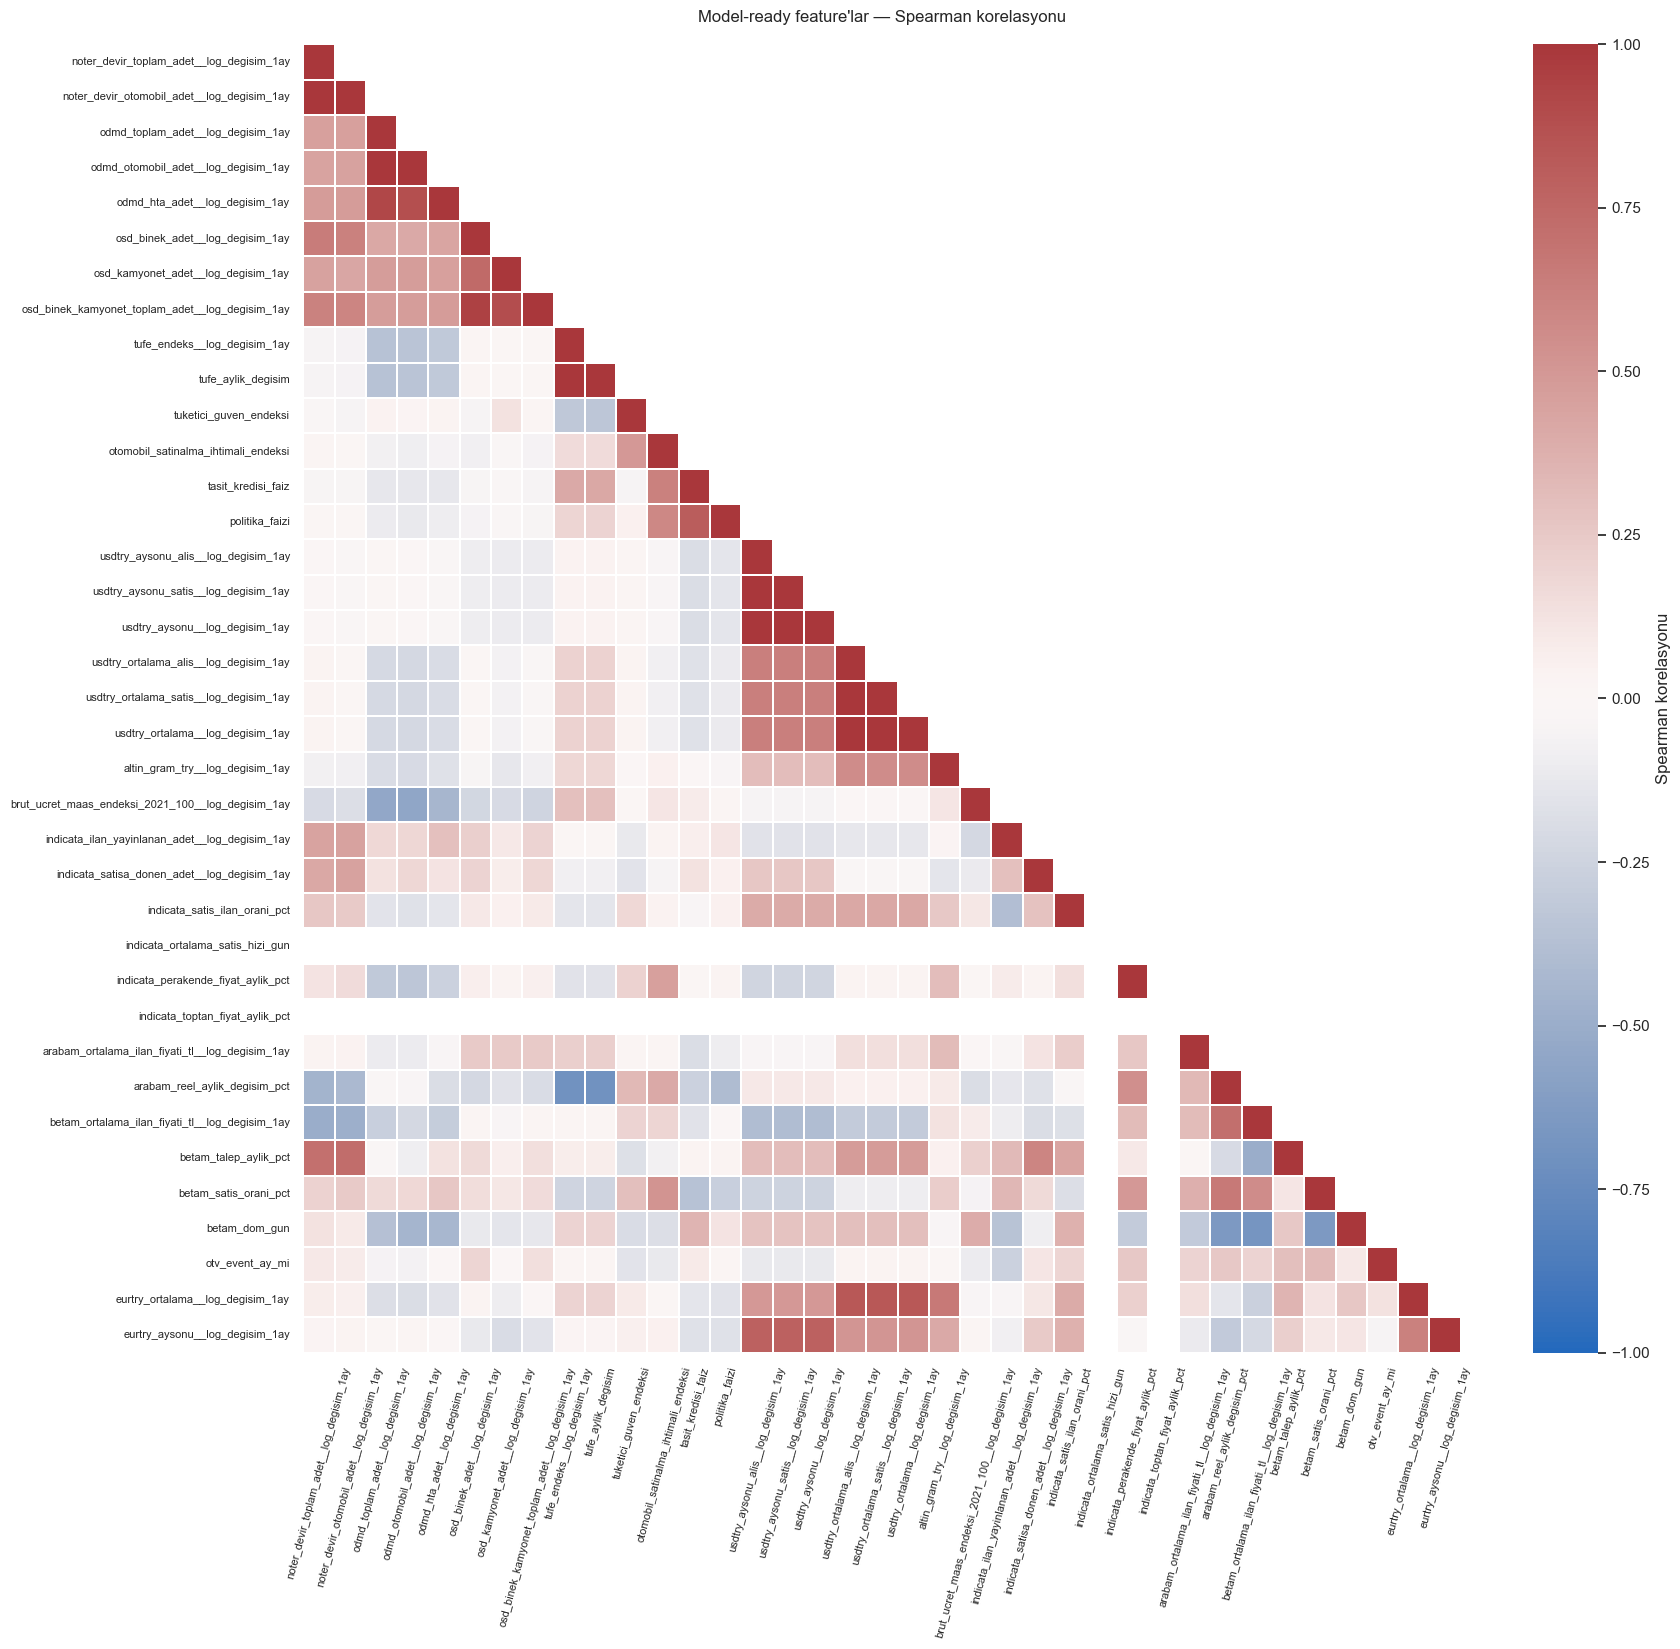

In [8]:
model_sayisal = model_feature[model_feature_sutunlari]
model_pearson, model_n = kare_isi_haritasi(
    model_sayisal,
    "Model-ready feature'lar — Pearson korelasyonu",
    "03_model_feature_pearson.png",
    method="pearson",
)
model_spearman, _ = kare_isi_haritasi(
    model_sayisal,
    "Model-ready feature'lar — Spearman korelasyonu",
    "04_model_feature_spearman.png",
    method="spearman",
)

## 8. Target alternatiflerinin korelasyon matrisi

Aynı kaynaktan türetilen log, yüzde ve simetrik target'ların birbirine çok yakın çıkması beklenir. Bu, üç farklı bilgi olduğu anlamına gelmez; aynı hareketin farklı ölçekleridir. Indicata ve fiyat target'ları ise farklı piyasa boyutlarını ölçer.

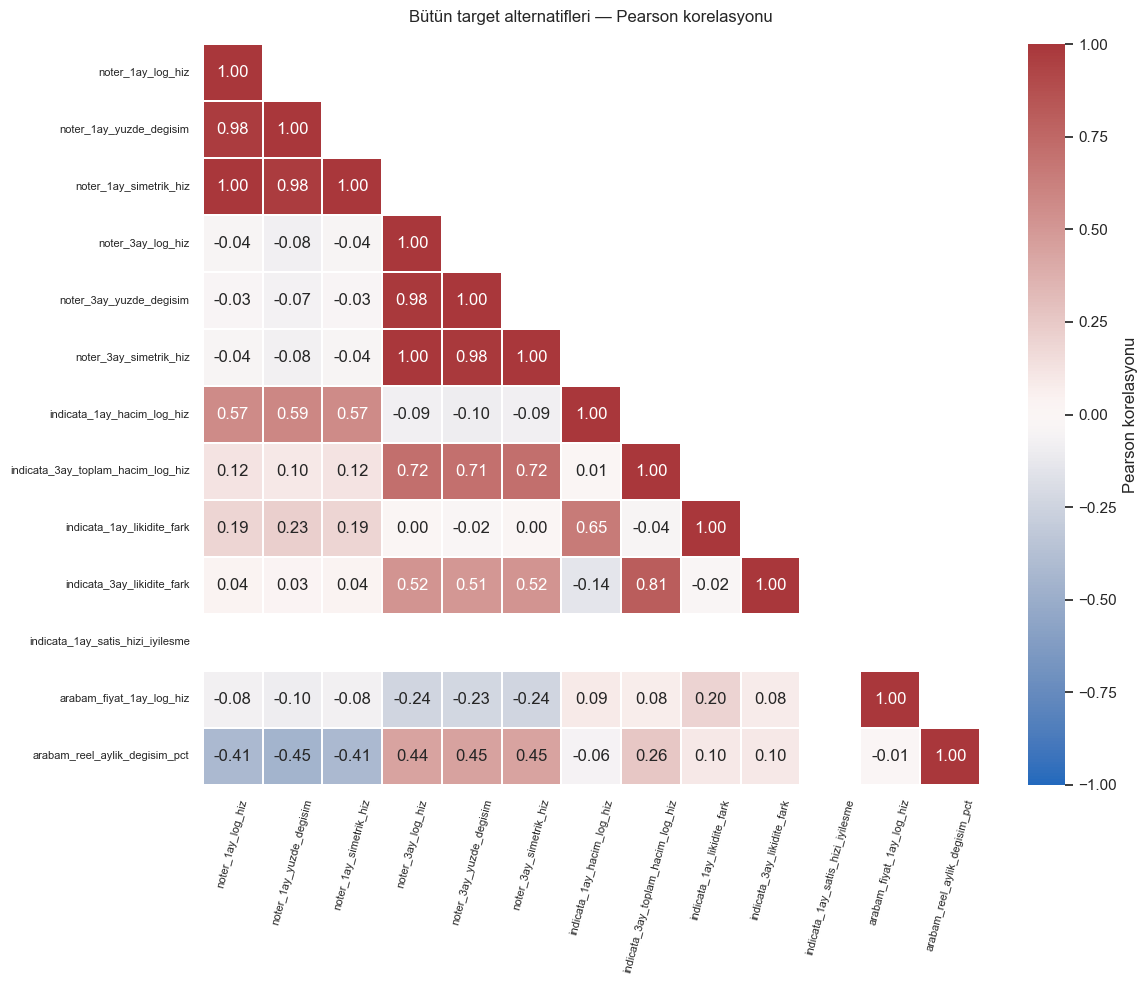

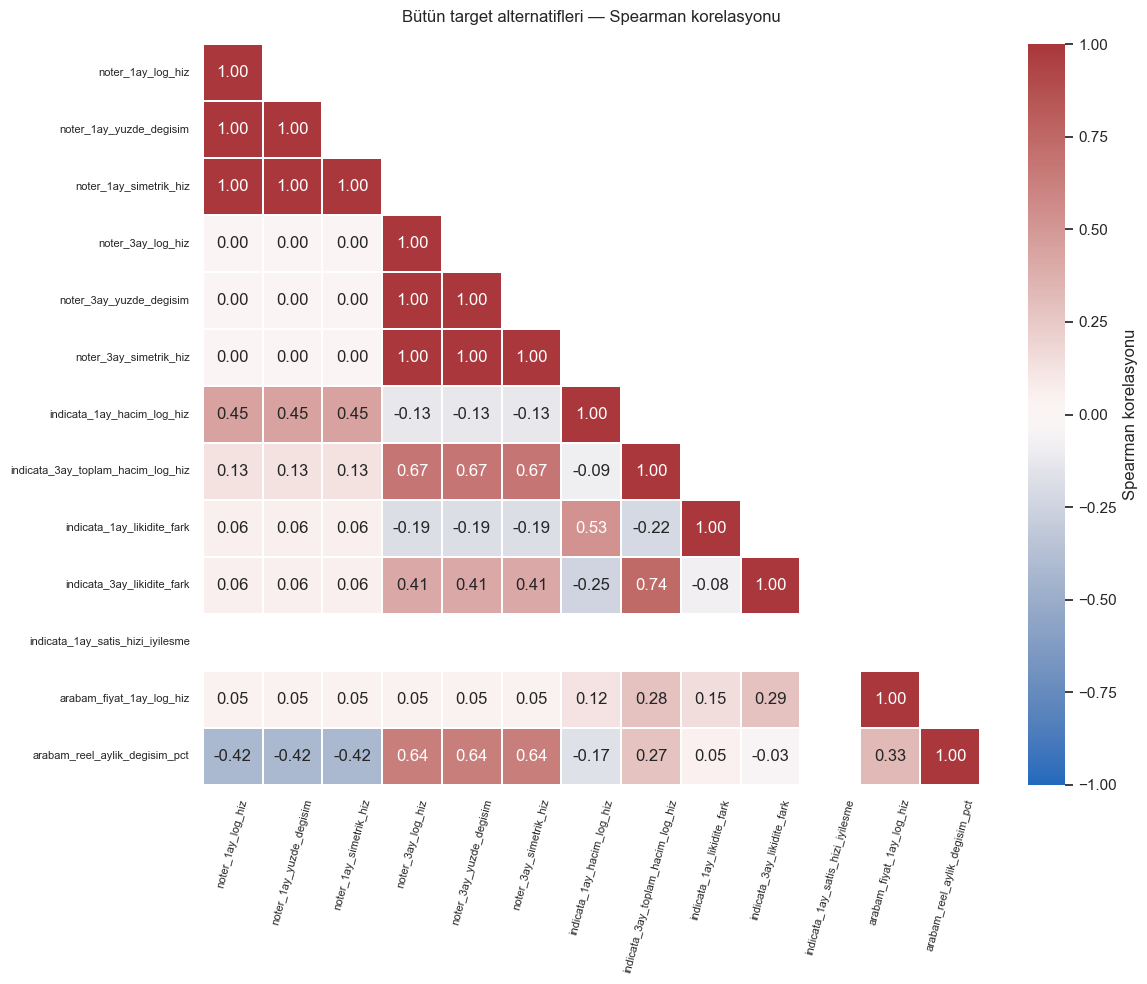

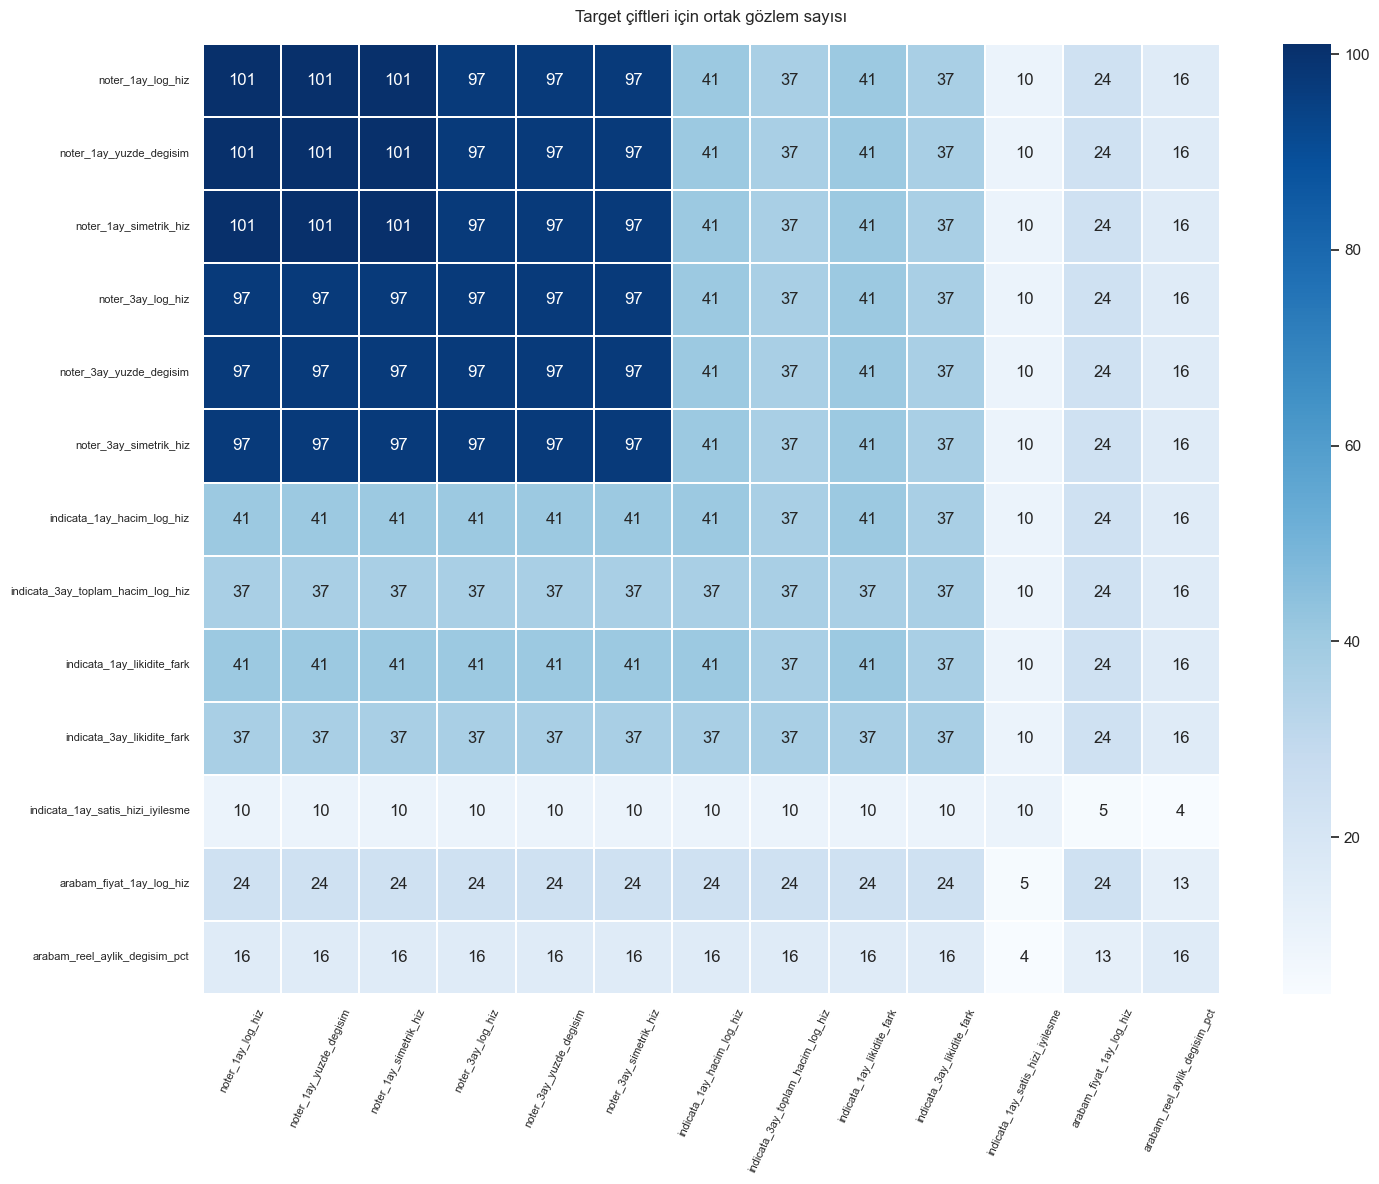

In [9]:
target_sutunlari = target_bilgisi["target"].tolist()
target_sayisal = targetlar[target_sutunlari]
target_pearson, target_n = kare_isi_haritasi(
    target_sayisal,
    "Bütün target alternatifleri — Pearson korelasyonu",
    "05_target_alternatifleri_pearson.png",
    method="pearson",
    annot=True,
)
target_spearman, _ = kare_isi_haritasi(
    target_sayisal,
    "Bütün target alternatifleri — Spearman korelasyonu",
    "06_target_alternatifleri_spearman.png",
    method="spearman",
    annot=True,
)

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(target_n, cmap="Blues", annot=True, fmt=".0f", linewidths=0.25, ax=ax)
ax.set_title("Target çiftleri için ortak gözlem sayısı", pad=16)
ax.tick_params(axis="x", rotation=65, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
fig.savefig(CIKTI_DIR / "07_target_ortak_gozlem_sayisi.png", dpi=220, bbox_inches="tight")
plt.show()

## 9. Eşzamanlı feature–target korelasyonları

Bu görünüm aynı ayda gerçekleşen feature ve target değerlerini karşılaştırır. Tanımlayıcı analiz için yararlıdır; tahmin performansı olarak yorumlanmamalıdır. Noter hacminden türetilen feature ile noter target'ı arasında mekanik ilişki bulunabilir.

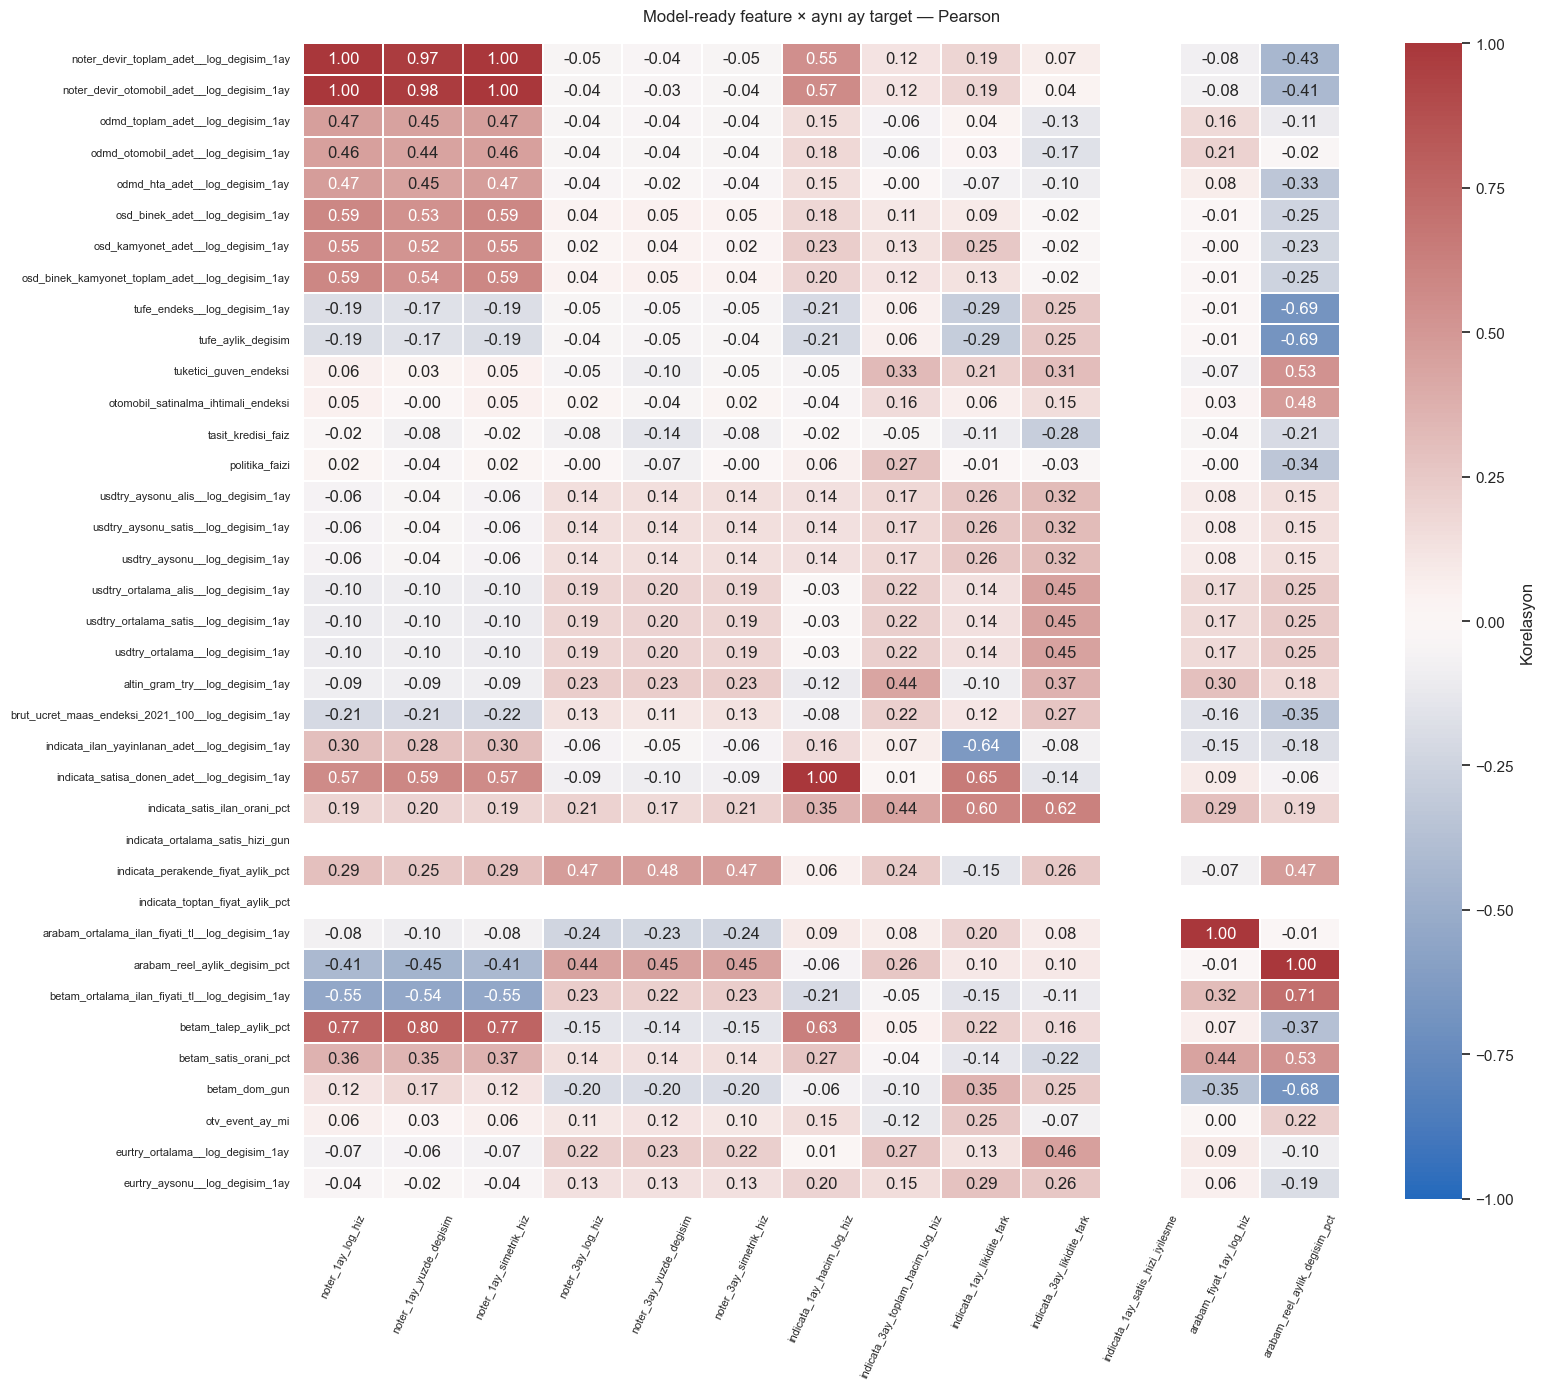

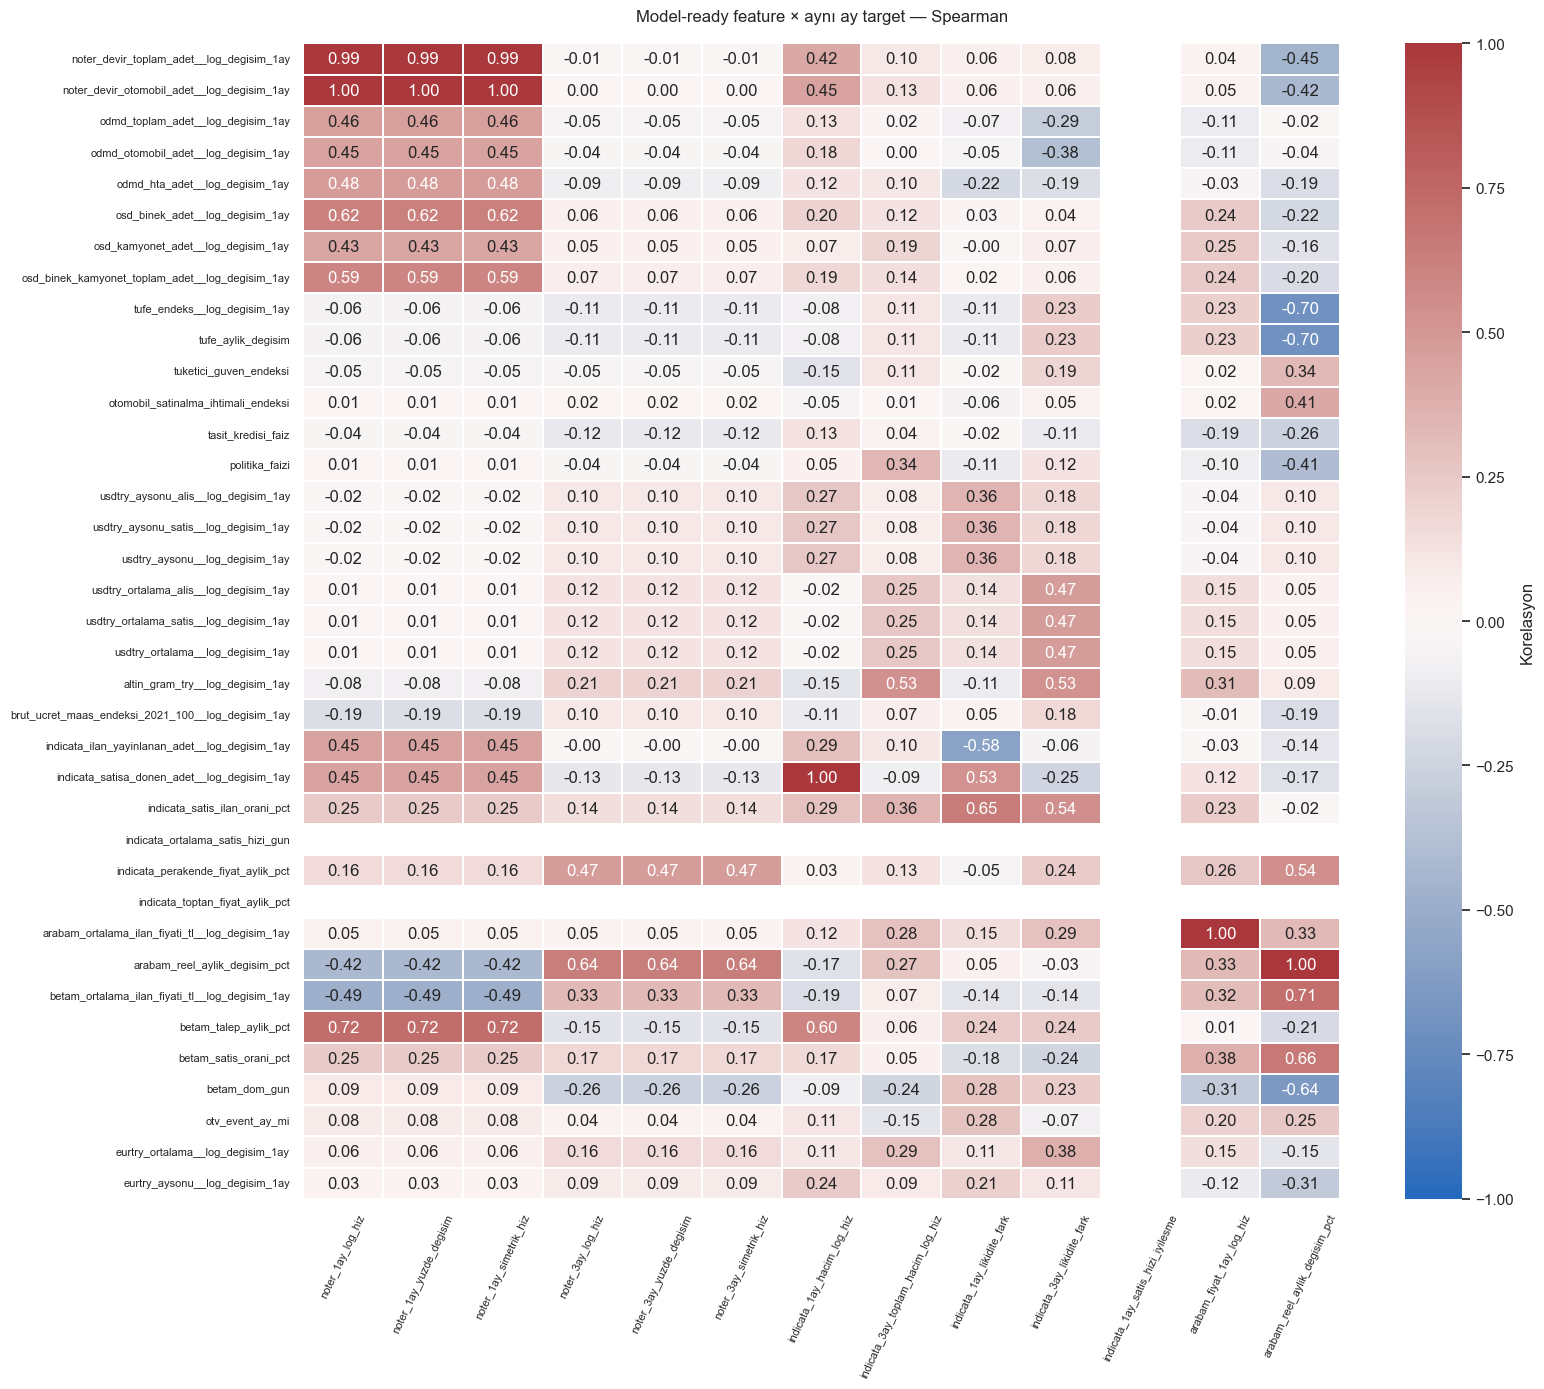

In [10]:
es_pearson, es_n = feature_target_corr(model_sayisal, target_sayisal, method="pearson")
es_spearman, _ = feature_target_corr(model_sayisal, target_sayisal, method="spearman")

dikdortgen_isi_haritasi(
    es_pearson, "Model-ready feature × aynı ay target — Pearson",
    "08_feature_target_eszamanli_pearson.png", annot=True,
)
dikdortgen_isi_haritasi(
    es_spearman, "Model-ready feature × aynı ay target — Spearman",
    "09_feature_target_eszamanli_spearman.png", annot=True,
)

## 10. Tahmin anına göre hizalanmış korelasyonlar

Burada feature ayı karar anı `t` kabul edilir. Bir aylık target `t+1`, üç aylık target ise `t+3` gerçekleşmesinden geriye hizalanır. Bu işlem model feature'ı üretmez; yalnızca geçmişte yapılabilecek tahmin ilişkisinin betimsel korelasyonunu ölçer. Negatif `shift`, yalnız analiz için gelecekte gerçekleşmiş target'ı origin satırına getirir ve model eğitim tablosuna kaydedilmez.

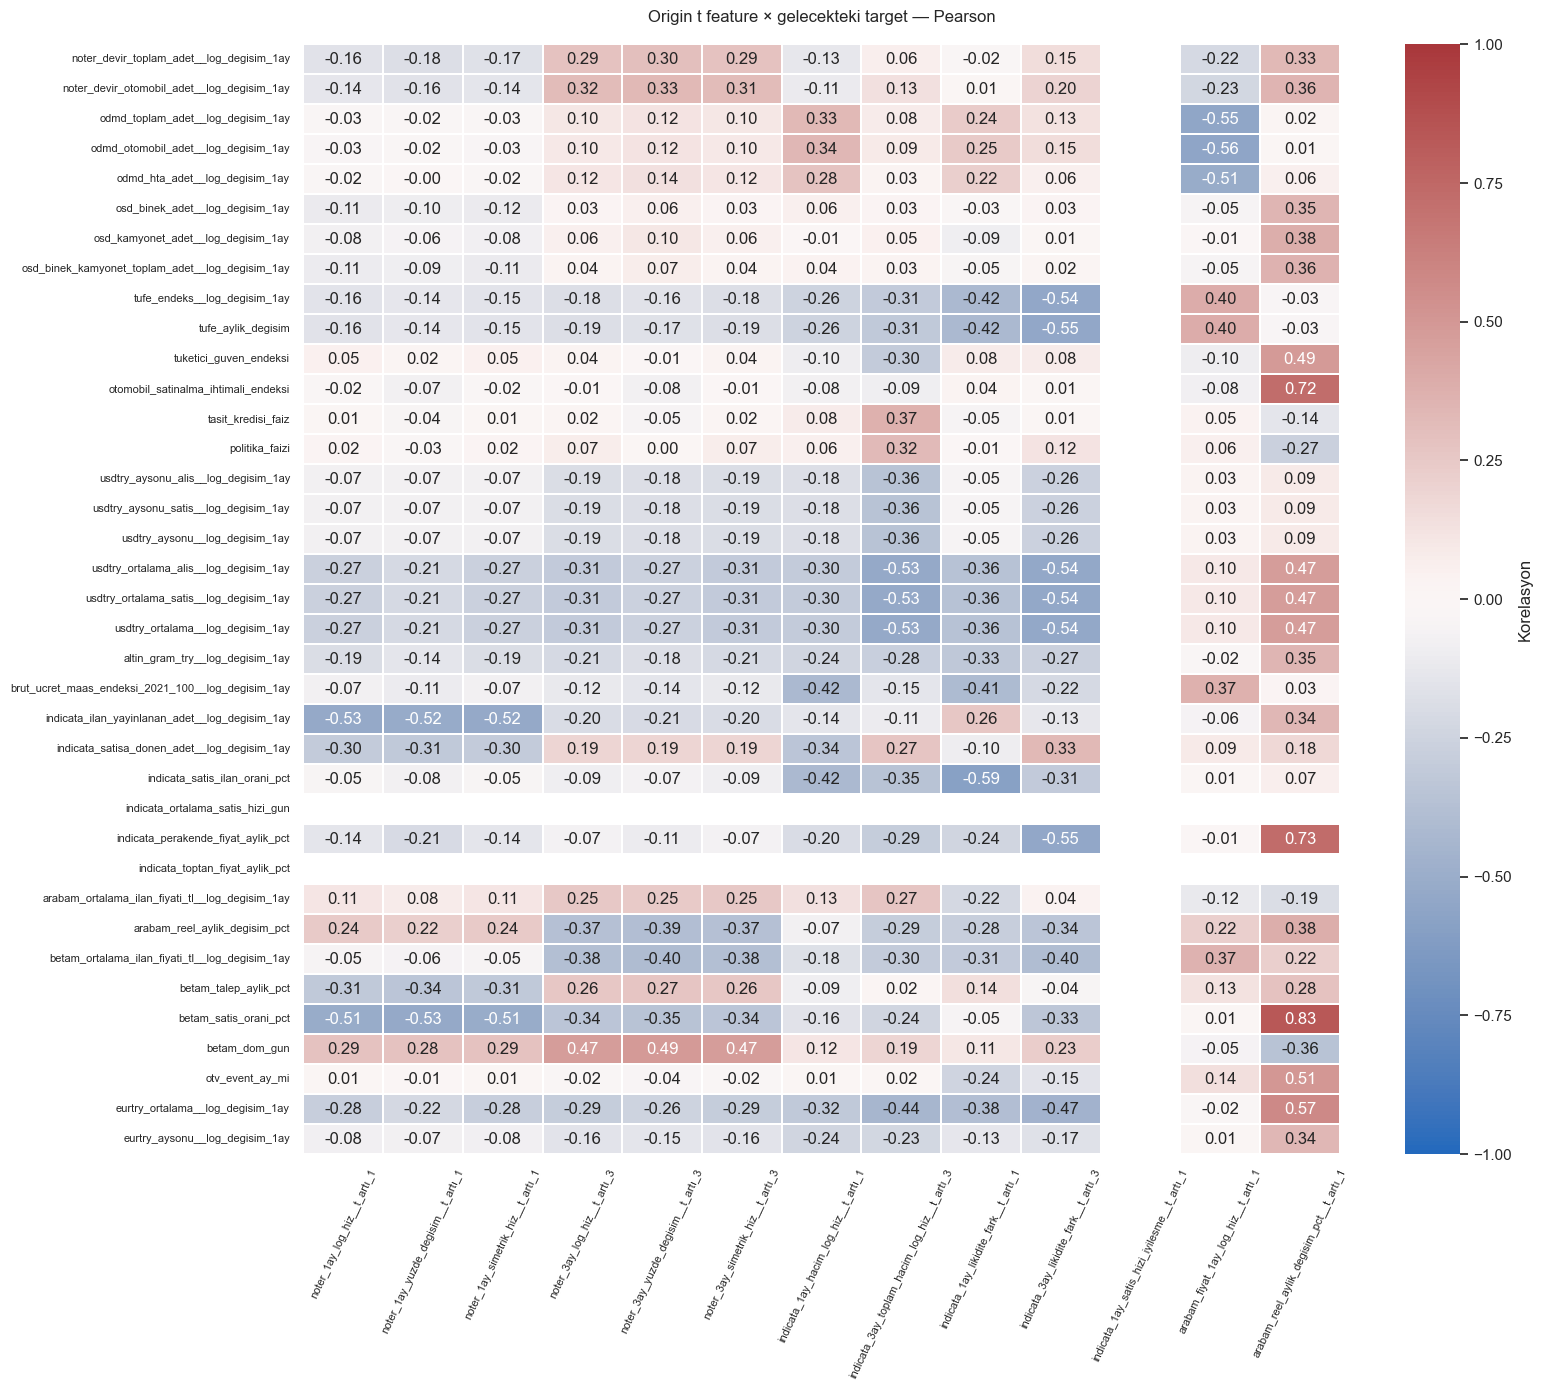

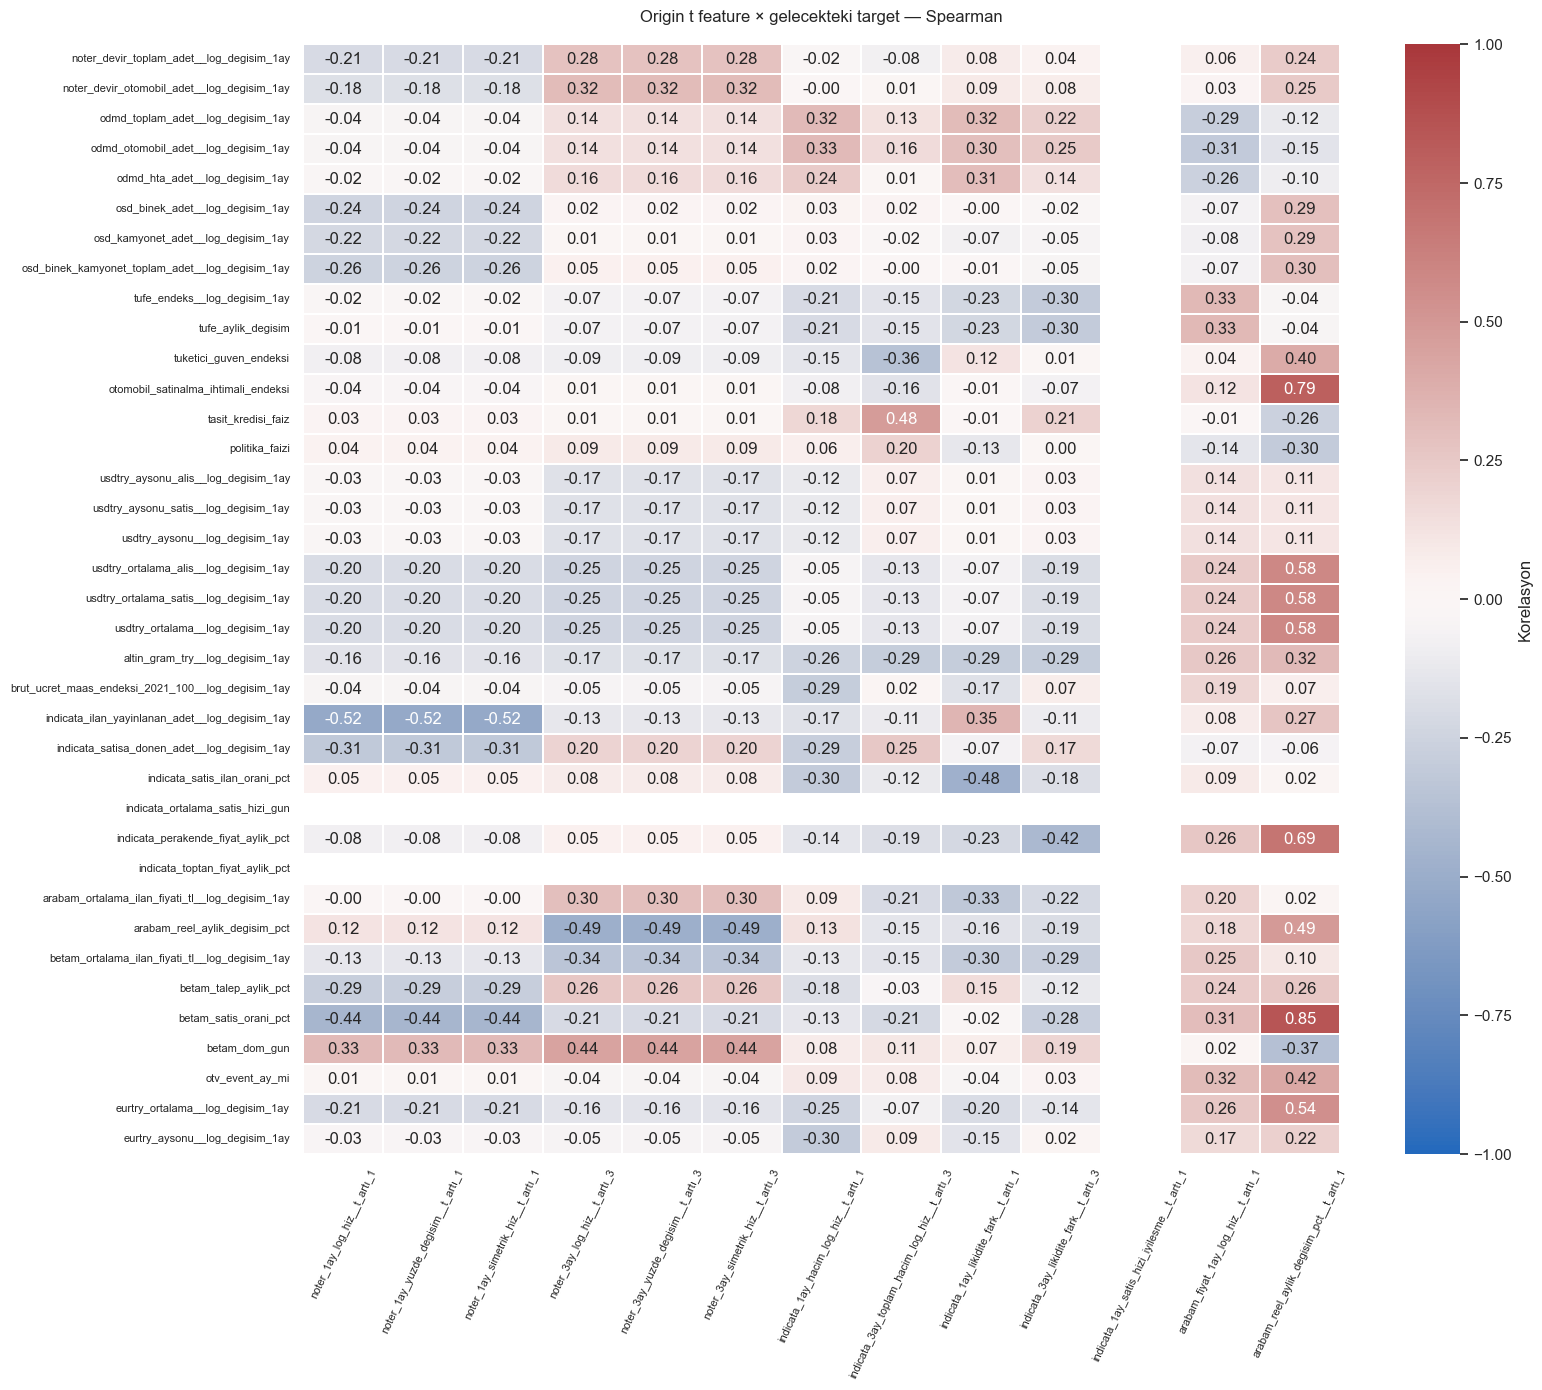

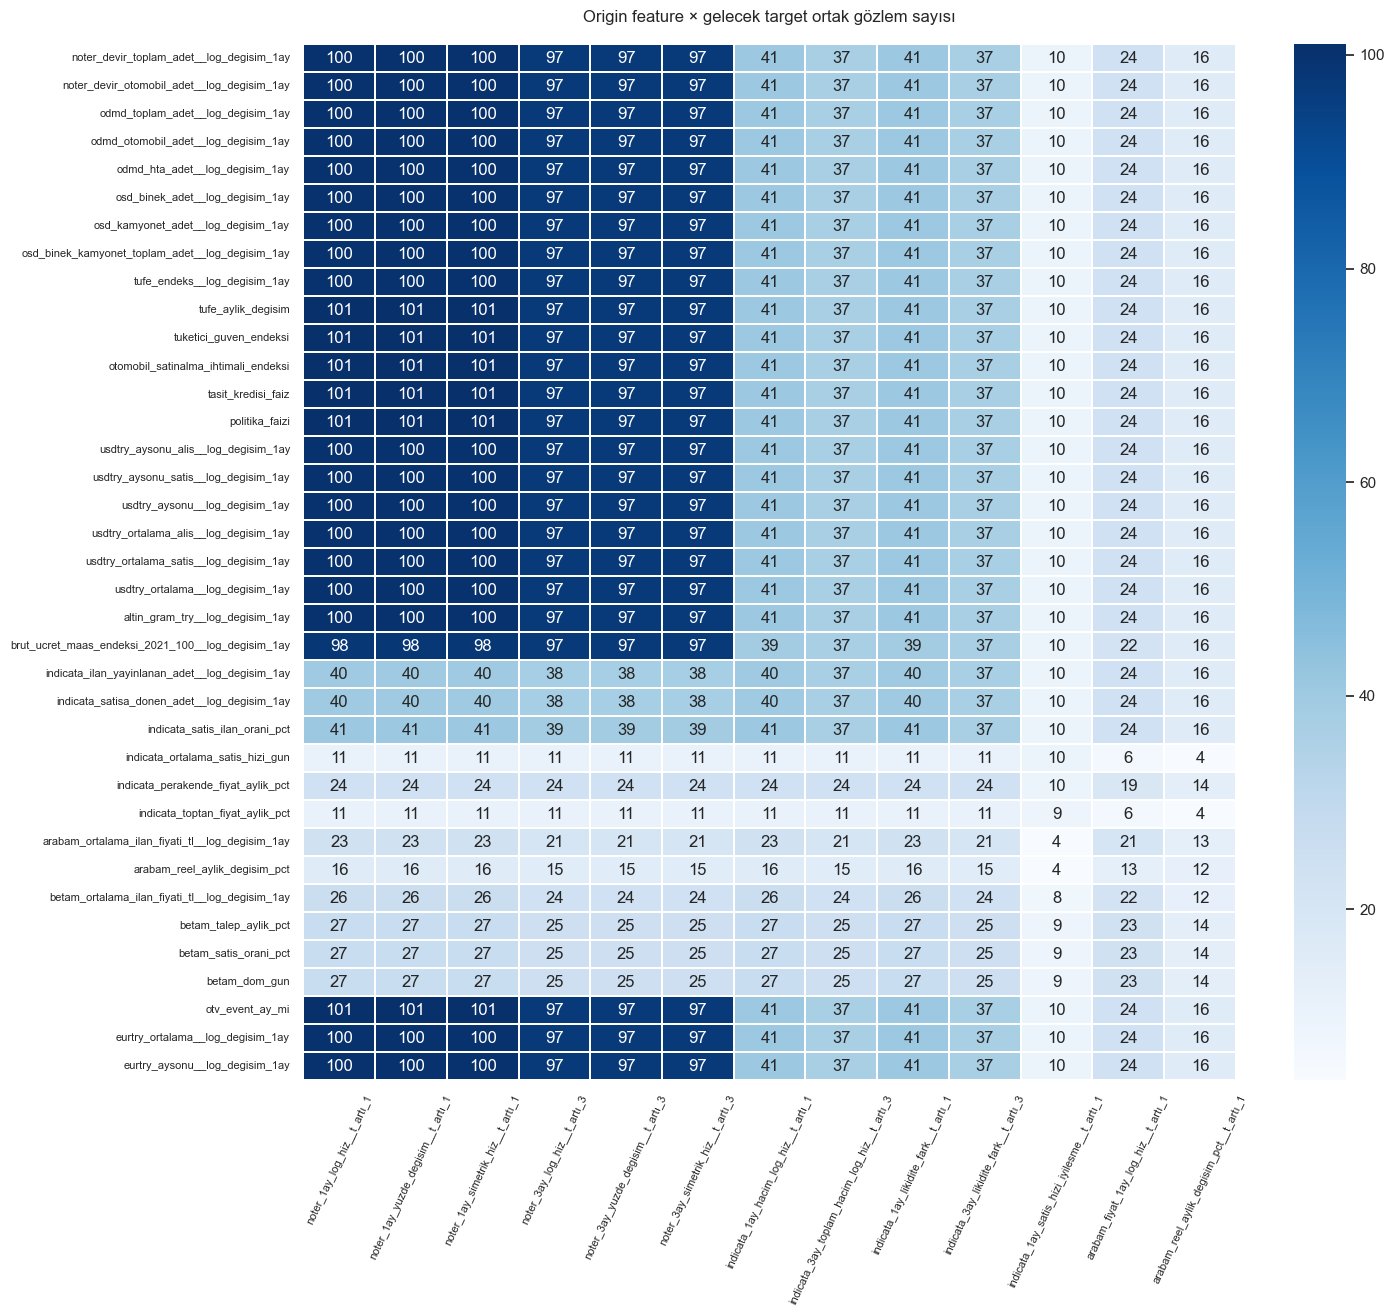

In [11]:
gelecek_target = pd.DataFrame(index=targetlar.index)
for _, satir in target_bilgisi.iterrows():
    target_adi = satir["target"]
    ufuk = int(satir["tahmin_ufku_ay"])
    gelecek_target[f"{target_adi}__t_artı_{ufuk}"] = targetlar[target_adi].shift(-ufuk)

ileri_pearson, ileri_n = feature_target_corr(model_sayisal, gelecek_target, method="pearson")
ileri_spearman, _ = feature_target_corr(model_sayisal, gelecek_target, method="spearman")

dikdortgen_isi_haritasi(
    ileri_pearson, "Origin t feature × gelecekteki target — Pearson",
    "10_feature_gelecek_target_pearson.png", annot=True,
)
dikdortgen_isi_haritasi(
    ileri_spearman, "Origin t feature × gelecekteki target — Spearman",
    "11_feature_gelecek_target_spearman.png", annot=True,
)

fig, ax = plt.subplots(figsize=(max(13, 1.15 * ileri_n.shape[1]), max(9, 0.36 * ileri_n.shape[0])))
sns.heatmap(ileri_n, cmap="Blues", annot=True, fmt=".0f", linewidths=0.25, ax=ax)
ax.set_title("Origin feature × gelecek target ortak gözlem sayısı", pad=16)
ax.tick_params(axis="x", rotation=65, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
fig.savefig(CIKTI_DIR / "12_feature_gelecek_target_ortak_gozlem.png", dpi=220, bbox_inches="tight")
plt.show()

## 11. Ana iki target için en güçlü ilişkileri yazdır

Mutlak korelasyona göre sıralama yalnız keşif amaçlıdır. Feature seçimi yapılırken korelasyonun zaman içinde kararlı olup olmadığı rolling-origin validasyonla ayrıca sınanmalıdır.

In [12]:
ana_gelecek_targetlar = [
    "noter_1ay_log_hiz__t_artı_1",
    "noter_3ay_log_hiz__t_artı_3",
]

sirali_listeler = []
for target_adi in ana_gelecek_targetlar:
    tablo = pd.DataFrame({
        "feature": ileri_pearson.index,
        "pearson": ileri_pearson[target_adi].values,
        "spearman": ileri_spearman[target_adi].values,
        "ortak_gozlem": ileri_n[target_adi].values,
    })
    tablo["mutlak_pearson"] = tablo["pearson"].abs()
    tablo["target"] = target_adi
    sirali_listeler.append(tablo.sort_values("mutlak_pearson", ascending=False).head(15))

en_guclu_iliskiler = pd.concat(sirali_listeler, ignore_index=True)
display(en_guclu_iliskiler[["target", "feature", "pearson", "spearman", "ortak_gozlem"]])

print("Kaydedilen grafikler:")
for yol in sorted(CIKTI_DIR.glob("*.png")):
    print("-", yol.name)

,target,feature,pearson,spearman,ortak_gozlem
0,noter_1ay_log_hiz__t_artı_1,indicata_ilan_yayinlanan_adet__log_degisim_1ay,-0.5250,-0.5244,40.0000
1,noter_1ay_log_hiz__t_artı_1,betam_satis_orani_pct,-0.5127,-0.4403,27.0000
2,noter_1ay_log_hiz__t_artı_1,betam_talep_aylik_pct,-0.3146,-0.2882,27.0000
3,noter_1ay_log_hiz__t_artı_1,indicata_satisa_donen_adet__log_degisim_1ay,-0.2979,-0.3137,40.0000
4,noter_1ay_log_hiz__t_artı_1,betam_dom_gun,0.2855,0.3253,27.0000
5,noter_1ay_log_hiz__t_artı_1,eurtry_ortalama__log_degisim_1ay,-0.2831,-0.2103,100.0000
6,noter_1ay_log_hiz__t_artı_1,usdtry_ortalama_alis__log_degisim_1ay,-0.2695,-0.1969,100.0000
7,noter_1ay_log_hiz__t_artı_1,usdtry_ortalama__log_degisim_1ay,-0.2695,-0.1969,100.0000
8,noter_1ay_log_hiz__t_artı_1,usdtry_ortalama_satis__log_degisim_1ay,-0.2695,-0.1969,100.0000
9,noter_1ay_log_hiz__t_artı_1,arabam_reel_aylik_degisim_pct,0.2440,0.1177,16.0000


Kaydedilen grafikler:
- 01_ham_feature_pearson.png
- 02_ham_feature_spearman.png
- 03_model_feature_pearson.png
- 04_model_feature_spearman.png
- 05_target_alternatifleri_pearson.png
- 06_target_alternatifleri_spearman.png
- 07_target_ortak_gozlem_sayisi.png
- 08_feature_target_eszamanli_pearson.png
- 09_feature_target_eszamanli_spearman.png
- 10_feature_gelecek_target_pearson.png
- 11_feature_gelecek_target_spearman.png
- 12_feature_gelecek_target_ortak_gozlem.png


## Yorumlama kontrol listesi

- `|r|` değerinin yüksek olması tek başına feature'ın faydalı olduğunu kanıtlamaz.
- Pearson doğrusal ilişkiyi, Spearman monoton ilişkiyi ölçer. İkisi farklıysa aykırı değer veya doğrusal olmayan ilişki olabilir.
- Ortak gözlem sayısı düşük ilişkileri güçlü kanıt olarak değerlendirmeyin.
- USD alış/satış/orta gibi birbirinin türevi feature'ların çok yüksek korelasyonu beklenir; modelleme öncesinde bunlardan biri seçilmelidir.
- Indicata'nın 2023 satırları sonradan yayımlanan karşılaştırma grafiklerinden türetildiği için 2023 gerçek zamanlı backtest feature'ı olarak kullanılamaz.
- Eşzamanlı korelasyon keşif içindir; tahmin açısından esas tablo `Origin t feature × gelecekteki target` görünümüdür.
- Nihai feature seçimi yalnız korelasyonla değil, kronolojik validasyon ve test başarısıyla yapılmalıdır.